# Notebook 2 - Exploratory Data Analysis

This notebook helps us answer four questions before we engineer features:

1. Are the cleaned tables structurally sound?
2. Are the keys, row grains, and join paths what we think they are?
3. Where is missingness **structural** versus truly problematic?
4. How do race distance, GPS coverage, and point-of-call structure vary across the data?

This notebook is intentionally heavy on:
- **sanity checks**
- **coverage checks**
- **distribution plots**
- **distance and point-of-call diagnostics**
- **join integrity audits**

It does **not** create model features yet.

## What this notebook expects

Best case: you have already run Notebook 1 and have these files in `data/processed/`:

- `laurel_gate_clean.csv`
- `laurel_horse_race_flat.csv`
- `pps_clean.csv`
- `gps_pp_clean.csv`
- `point_of_call_profile_by_distance.csv`

If those files do not exist yet, this notebook can fall back to the raw workbook and do a **minimal clean/load** so you can still explore the data.

In [2]:
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
warnings.filterwarnings("ignore")

In [3]:
# ---------------------------------------------------------
# Path discovery
# ---------------------------------------------------------
PROCESSED_DIR_CANDIDATES = [
    Path("data/processed"),
    Path("../data/processed"),
]

RAW_WORKBOOK_CANDIDATES = [
    Path("data/raw/GPS Races for LRL Practice Round.xlsx"),
    Path("../data/raw/GPS Races for LRL Practice Round.xlsx"),
]

EDA_DIR = Path("../data/eda")
EDA_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_DIR = next((p for p in PROCESSED_DIR_CANDIDATES if p.exists()), None)
RAW_WORKBOOK = next((p for p in RAW_WORKBOOK_CANDIDATES if p.exists()), None)

PROCESSED_DIR, RAW_WORKBOOK

(PosixPath('../data/processed'),
 PosixPath('../data/raw/GPS Races for LRL Practice Round.xlsx'))

## Load the processed outputs if available; otherwise fall back to the raw workbook

The processed-path branch is ideal because it respects your cleaning decisions from Notebook 1.

The raw-workbook fallback only performs enough cleaning to support EDA:
- standardize names
- strip whitespace
- parse dates
- create keys
- make a simple flat Laurel table from the final gate row

In [4]:
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    cols = (
        pd.Index(out.columns)
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("?", "", regex=False)
        .str.replace(r"[^0-9a-zA-Z]+", "_", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    out.columns = cols
    return out

def strip_strings_and_blank_to_nan(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.select_dtypes(include="object").columns:
        out[col] = out[col].map(lambda x: x.strip() if isinstance(x, str) else x)
        out[col] = out[col].replace({"": np.nan, " ": np.nan})
    return out

def create_basic_keys(laurel_gate: pd.DataFrame, pps: pd.DataFrame, gps_pp: pd.DataFrame):
    # Laurel keys
    if {"track_id", "race_date", "race_number", "registration_number"}.issubset(laurel_gate.columns):
        laurel_gate["track_id"] = laurel_gate["track_id"].astype(str).str.strip()
        laurel_gate["registration_number"] = laurel_gate["registration_number"].astype(str).str.strip()
        laurel_gate["race_key"] = (
            laurel_gate["track_id"].astype(str)
            + "_"
            + laurel_gate["race_date"].dt.strftime("%Y-%m-%d")
            + "_"
            + laurel_gate["race_number"].astype("Int64").astype(str)
        )
        laurel_gate["horse_race_key"] = laurel_gate["race_key"] + "_" + laurel_gate["registration_number"]

    # PP keys
    if {"pp_track", "pp_race_date", "pp_race_number", "registration_number"}.issubset(pps.columns):
        pps["pp_track"] = pps["pp_track"].astype(str).str.strip()
        pps["registration_number"] = pps["registration_number"].astype(str).str.strip()
        pps["pp_race_key"] = (
            pps["registration_number"].astype(str)
            + "_"
            + pps["pp_track"].astype(str)
            + "_"
            + pps["pp_race_date"].dt.strftime("%Y-%m-%d")
            + "_"
            + pps["pp_race_number"].astype("Int64").astype(str)
        )

    if {"pp_track", "pp_race_date", "pp_race_number", "registration_number"}.issubset(gps_pp.columns):
        gps_pp["pp_track"] = gps_pp["pp_track"].astype(str).str.strip()
        gps_pp["registration_number"] = gps_pp["registration_number"].astype(str).str.strip()
        gps_pp["pp_race_key"] = (
            gps_pp["registration_number"].astype(str)
            + "_"
            + gps_pp["pp_track"].astype(str)
            + "_"
            + gps_pp["pp_race_date"].dt.strftime("%Y-%m-%d")
            + "_"
            + gps_pp["pp_race_number"].astype("Int64").astype(str)
        )
    return laurel_gate, pps, gps_pp

FURLONG_TO_METERS = 201.168

def add_distance_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "distance_id" in out.columns:
        out["distance_furlongs"] = pd.to_numeric(out["distance_id"], errors="coerce")
        out["distance_meters_expected"] = out["distance_furlongs"] * FURLONG_TO_METERS
    if "distance" in out.columns:
        out["distance_label"] = out["distance"].astype(str).str.strip()
    if "published_value" in out.columns:
        out["distance_label"] = out["published_value"].astype(str).str.strip()
    if "distance_label" in out.columns:
        out["is_nonstandard_distance"] = out["distance_label"].str.contains("Y", na=False).astype(int)
    return out

def handle_structural_missing(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "about_distance_indicator" in out.columns:
        out["about_distance_indicator"] = out["about_distance_indicator"].fillna("").astype(str).str.strip()
        out["is_about_distance"] = (out["about_distance_indicator"] == "A").astype(int)

    if "grade" in out.columns:
        out["grade"] = pd.to_numeric(out["grade"], errors="coerce")
        out["is_graded_race"] = out["grade"].notna().astype(int)
        out["grade_filled"] = out["grade"].fillna(0)

    # Accept either the renamed or original PP GPS-flag column
    for gps_flag_col in ["gps_data_flag", "gps_data", "gps_date"]:
        if gps_flag_col in out.columns:
            out[gps_flag_col] = out[gps_flag_col].fillna("").astype(str).str.strip()
            out["has_gps_data"] = (out[gps_flag_col] == "X").astype(int)
            break

    return out

def load_raw_fallback(raw_workbook: Path):
    workbook = pd.ExcelFile(raw_workbook)

    laurel = strip_strings_and_blank_to_nan(
        standardize_columns(workbook.parse("Laurel Park GPS races (past 60d"))
    )
    pps = strip_strings_and_blank_to_nan(
        standardize_columns(workbook.parse("Starters pps (relating to Laure"))
    )
    gps_pp = strip_strings_and_blank_to_nan(
        standardize_columns(workbook.parse("GPS PPS"))
    )

    if "gps_date" in pps.columns:
        pps = pps.rename(columns={"gps_date": "gps_data_flag"})

    laurel["race_date"] = pd.to_datetime(laurel["race_date"])
    pps["pp_race_date"] = pd.to_datetime(pps["pp_race_date"])
    gps_pp["pp_race_date"] = pd.to_datetime(gps_pp["pp_race_date"])

    laurel = add_distance_columns(handle_structural_missing(laurel))
    pps = add_distance_columns(handle_structural_missing(pps))
    gps_pp = add_distance_columns(handle_structural_missing(gps_pp))

    laurel, pps, gps_pp = create_basic_keys(laurel, pps, gps_pp)

    # Simple Laurel flatten: take the minimum gate row as the final gate row (usually 0)
    gate_min = laurel.groupby("horse_race_key")["gate"].transform("min")
    laurel_flat = (
        laurel.loc[laurel["gate"].eq(gate_min)]
        .sort_values(["race_date", "race_number", "post_position", "horse_name"])
        .drop_duplicates("horse_race_key")
        .copy()
    )

    laurel_gate_counts = laurel.groupby("horse_race_key").size().rename("n_gate_rows")
    laurel_flat = laurel_flat.merge(laurel_gate_counts, on="horse_race_key", how="left")

    # Point-of-call profile from pps
    poc_position_cols = [c for c in pps.columns if c.startswith("position_at_point_of_call_")]
    poc_profile = (
        pps.assign(
            n_active_pocs=pps[poc_position_cols].fillna(0).gt(0).sum(axis=1)
        )
        .groupby(["distance_label", "distance_furlongs"], dropna=False)
        .agg(
            n_rows=("registration_number", "size"),
            avg_active_pocs=("n_active_pocs", "mean"),
            share_nonstandard=("is_nonstandard_distance", "mean"),
        )
        .reset_index()
        .sort_values(["distance_furlongs", "distance_label"])
    )

    return laurel, laurel_flat, pps, gps_pp, poc_profile

if PROCESSED_DIR is not None and all(
    (PROCESSED_DIR / f).exists()
    for f in [
        "laurel_gate_clean.csv",
        "laurel_horse_race_flat.csv",
        "pps_clean.csv",
        "gps_pp_clean.csv",
    ]
):
    laurel_gate = pd.read_csv(PROCESSED_DIR / "laurel_gate_clean.csv", parse_dates=["race_date"])
    laurel_flat = pd.read_csv(PROCESSED_DIR / "laurel_horse_race_flat.csv", parse_dates=["race_date"])
    pps_clean = pd.read_csv(PROCESSED_DIR / "pps_clean.csv", parse_dates=["pp_race_date"])
    gps_pp_clean = pd.read_csv(PROCESSED_DIR / "gps_pp_clean.csv", parse_dates=["pp_race_date"])

    poc_profile_path = PROCESSED_DIR / "point_of_call_profile_by_distance.csv"
    if poc_profile_path.exists():
        point_of_call_profile_by_distance = pd.read_csv(poc_profile_path)
    else:
        point_of_call_profile_by_distance = pd.DataFrame()

    source_mode = "processed_files"
else:
    if RAW_WORKBOOK is None:
        raise FileNotFoundError(
            "Could not find either data/processed outputs or the raw Excel workbook."
        )
    laurel_gate, laurel_flat, pps_clean, gps_pp_clean, point_of_call_profile_by_distance = load_raw_fallback(RAW_WORKBOOK)
    source_mode = "raw_workbook_fallback"

source_mode

'processed_files'

In [5]:
inventory = pd.DataFrame(
    {
        "table": [
            "laurel_gate",
            "laurel_flat",
            "pps_clean",
            "gps_pp_clean",
            "point_of_call_profile_by_distance",
        ],
        "rows": [
            len(laurel_gate),
            len(laurel_flat),
            len(pps_clean),
            len(gps_pp_clean),
            len(point_of_call_profile_by_distance),
        ],
        "columns": [
            laurel_gate.shape[1],
            laurel_flat.shape[1],
            pps_clean.shape[1],
            gps_pp_clean.shape[1],
            point_of_call_profile_by_distance.shape[1],
        ],
    }
)
inventory

,table,rows,columns
0,laurel_gate,14642,31
1,laurel_flat,1054,186
2,pps_clean,2293,44
3,gps_pp_clean,23971,33
4,point_of_call_profile_by_distance,18,11


## 1. Table grain and key integrity

This section answers:
- what one row means in each table
- whether the key columns are unique at the expected level
- how many gate rows each horse-race has in the GPS tables

In [6]:
def duplicate_report(df: pd.DataFrame, key_cols: list[str], label: str) -> pd.DataFrame:
    dup_mask = df.duplicated(key_cols, keep=False)
    return pd.DataFrame(
        {
            "table": [label],
            "key": [", ".join(key_cols)],
            "n_rows": [len(df)],
            "n_unique_keys": [df[key_cols].drop_duplicates().shape[0]],
            "n_duplicate_rows": [int(dup_mask.sum())],
        }
    )

reports = [
    duplicate_report(laurel_gate, ["horse_race_key", "gate"], "laurel_gate"),
    duplicate_report(laurel_flat, ["horse_race_key"], "laurel_flat"),
    duplicate_report(pps_clean, ["pp_race_key"], "pps_clean") if "pp_race_key" in pps_clean.columns else pd.DataFrame(),
    duplicate_report(gps_pp_clean, ["pp_race_key", "gate"], "gps_pp_clean") if "pp_race_key" in gps_pp_clean.columns else pd.DataFrame(),
]
grain_report = pd.concat([r for r in reports if not r.empty], ignore_index=True)
grain_report

,table,key,n_rows,n_unique_keys,n_duplicate_rows
0,laurel_gate,"horse_race_key, gate",14642,14642,0
1,laurel_flat,horse_race_key,1054,1054,0
2,pps_clean,pp_race_key,2293,2293,0
3,gps_pp_clean,"pp_race_key, gate",23971,23971,0


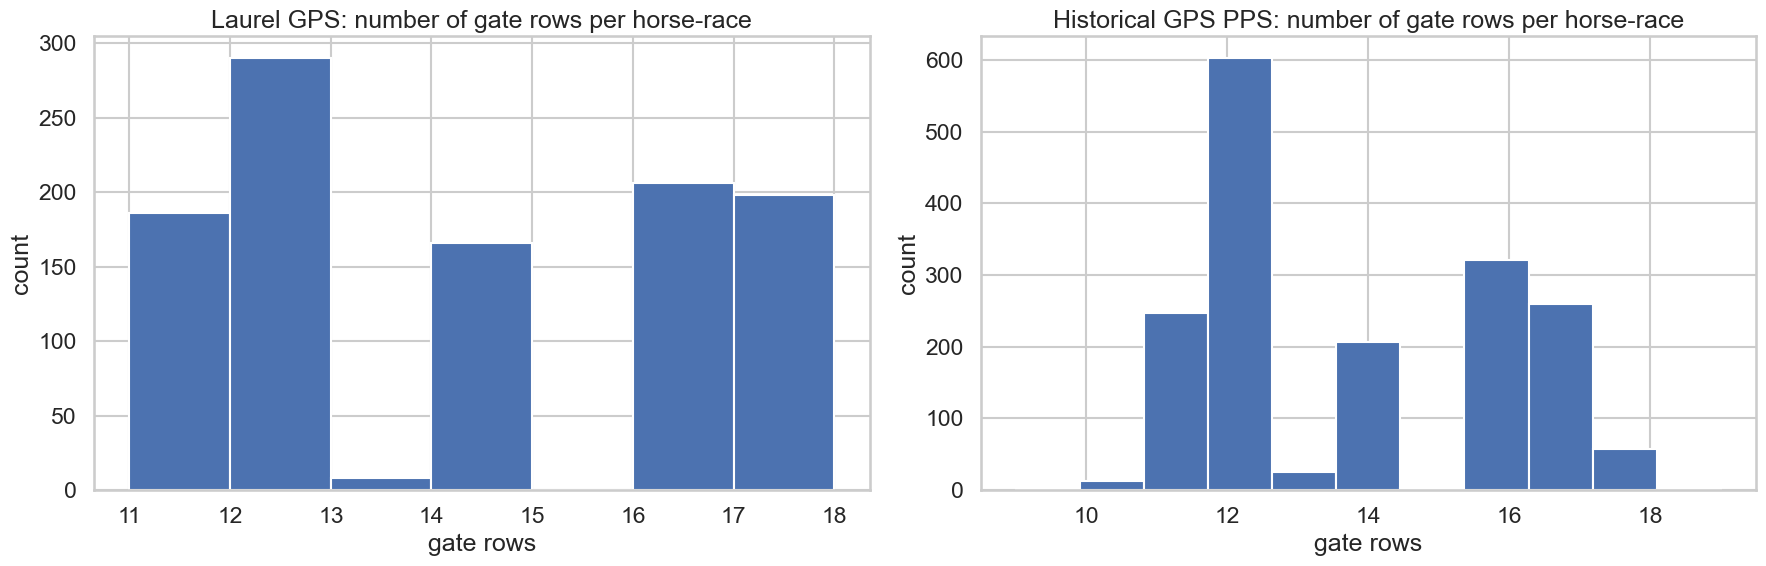

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

if "horse_race_key" in laurel_gate.columns:
    laurel_gate_counts = laurel_gate.groupby("horse_race_key").size()
    axes[0].hist(laurel_gate_counts, bins=min(30, laurel_gate_counts.nunique()))
    axes[0].set_title("Laurel GPS: number of gate rows per horse-race")
    axes[0].set_xlabel("gate rows")
    axes[0].set_ylabel("count")

if "pp_race_key" in gps_pp_clean.columns:
    gps_gate_counts = gps_pp_clean.groupby("pp_race_key").size()
    axes[1].hist(gps_gate_counts, bins=min(30, gps_gate_counts.nunique()))
    axes[1].set_title("Historical GPS PPS: number of gate rows per horse-race")
    axes[1].set_xlabel("gate rows")
    axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

In [8]:
# Save the grain report now because it is useful later.
grain_report.to_csv(EDA_DIR / "grain_report.csv", index=False)
grain_report

,table,key,n_rows,n_unique_keys,n_duplicate_rows
0,laurel_gate,"horse_race_key, gate",14642,14642,0
1,laurel_flat,horse_race_key,1054,1054,0
2,pps_clean,pp_race_key,2293,2293,0
3,gps_pp_clean,"pp_race_key, gate",23971,23971,0


## 2. Missingness audit

Not all missingness is bad.

Examples of **structural missingness** in this dataset:
- `grade` is blank for most races because most races are not graded stakes
- `about_distance_indicator` is blank for exact distances
- the PP GPS flag is blank when a past-performance race does not have GPS

The goal here is to visualize missingness and separate the *expected* blanks from the ones we should inspect more closely.

In [9]:
def missing_summary(df: pd.DataFrame, table_name: str) -> pd.DataFrame:
    out = (
        df.isna()
        .mean()
        .rename("missing_share")
        .reset_index()
        .rename(columns={"index": "column"})
    )
    out["missing_pct"] = 100 * out["missing_share"]
    out["table"] = table_name
    return out.sort_values("missing_pct", ascending=False)

missing_all = pd.concat(
    [
        missing_summary(laurel_gate, "laurel_gate"),
        missing_summary(laurel_flat, "laurel_flat"),
        missing_summary(pps_clean, "pps_clean"),
        missing_summary(gps_pp_clean, "gps_pp_clean"),
    ],
    ignore_index=True,
)
missing_all.head(20)

,column,missing_share,missing_pct,table
0,track_id,0.0,0.0,laurel_gate
1,running_time,0.0,0.0,laurel_gate
2,race_key,0.0,0.0,laurel_gate
3,is_nonstandard_distance,0.0,0.0,laurel_gate
4,distance_label,0.0,0.0,laurel_gate
5,distance_meters_expected,0.0,0.0,laurel_gate
6,distance_furlongs,0.0,0.0,laurel_gate
7,is_graded_race,0.0,0.0,laurel_gate
8,is_about_distance,0.0,0.0,laurel_gate
9,cumulative_strides,0.0,0.0,laurel_gate


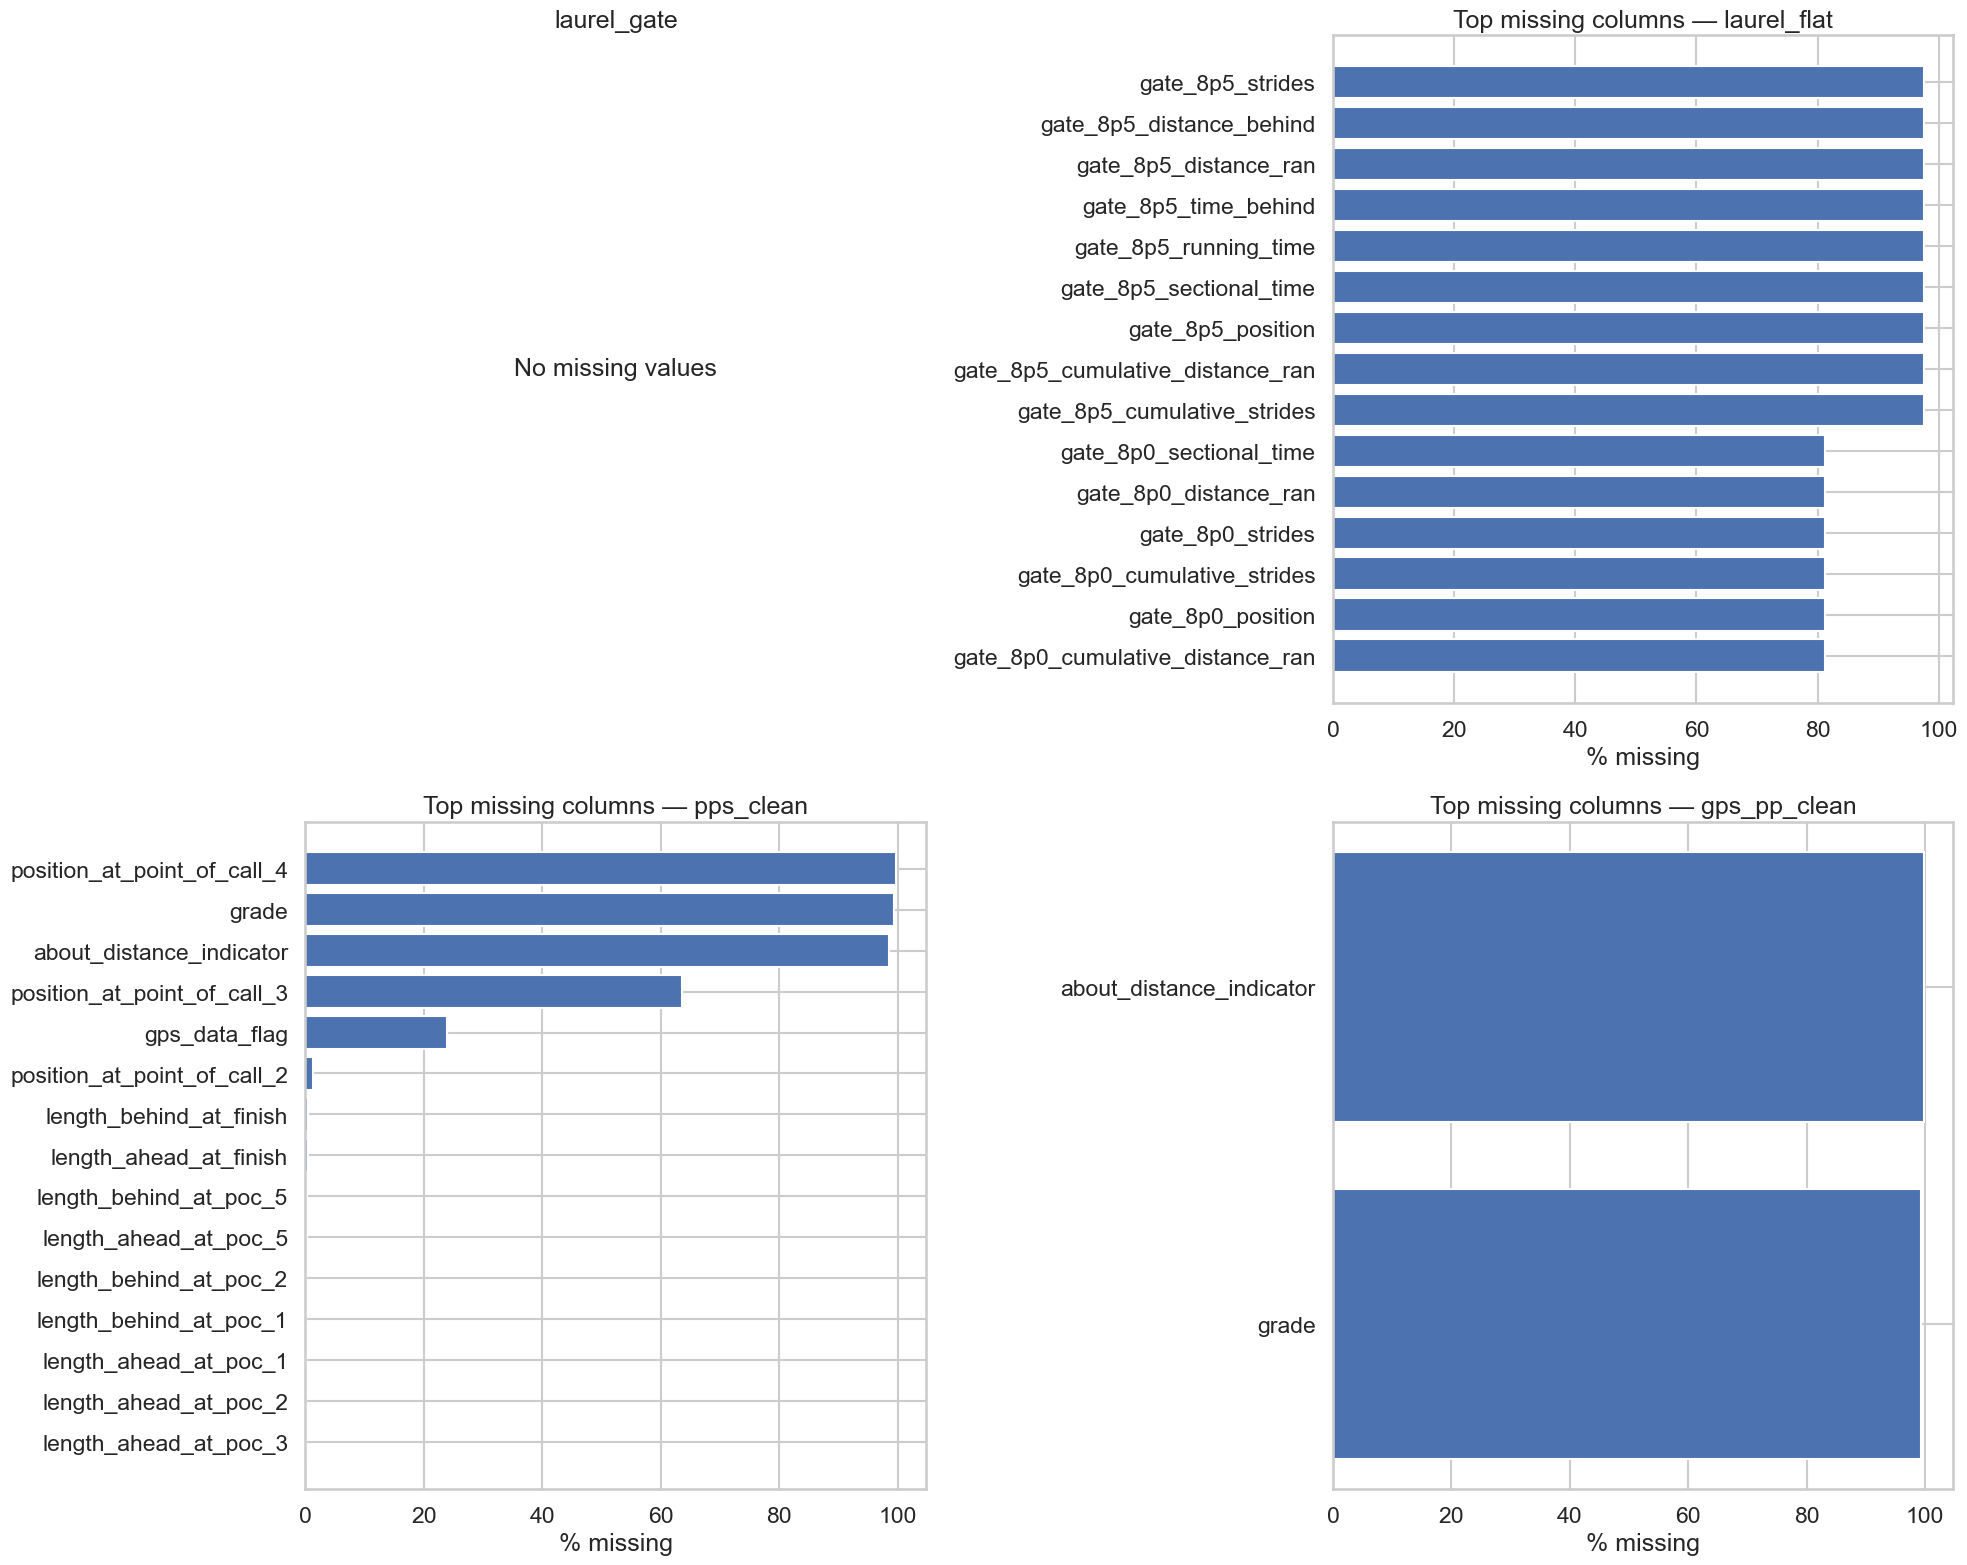

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
for ax, (name, df) in zip(
    axes.flatten(),
    [
        ("laurel_gate", laurel_gate),
        ("laurel_flat", laurel_flat),
        ("pps_clean", pps_clean),
        ("gps_pp_clean", gps_pp_clean),
    ],
):
    ms = missing_summary(df, name).query("missing_pct > 0").head(15).sort_values("missing_pct")
    if ms.empty:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center")
        ax.set_title(name)
        ax.axis("off")
        continue
    ax.barh(ms["column"], ms["missing_pct"])
    ax.set_title(f"Top missing columns — {name}")
    ax.set_xlabel("% missing")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [11]:
structural_missing_catalog = pd.DataFrame(
    {
        "column": ["about_distance_indicator", "grade", "gps_data_flag", "has_gps_data"],
        "expected_interpretation": [
            "Blank usually means exact distance, not unknown distance.",
            "Blank usually means not a graded stakes race.",
            "Blank usually means that prior race does not have GPS.",
            "0 means no historical GPS coverage flag; not a data-quality failure.",
        ],
    }
)
structural_missing_catalog

,column,expected_interpretation
0,about_distance_indicator,"Blank usually means exact distance, not unknow..."
1,grade,Blank usually means not a graded stakes race.
2,gps_data_flag,Blank usually means that prior race does not h...
3,has_gps_data,0 means no historical GPS coverage flag; not a...


## 3. Laurel target-race profile

This section focuses on the **current Laurel Park races**, which are the target races for the project.

We examine:
- calendar coverage
- field size
- race composition
- distance mix
- outcome distribution

In [12]:
# Add finish-percentile if missing
if "finish_percentile" not in laurel_flat.columns and {"official_position", "field_size"}.issubset(laurel_flat.columns):
    denom = (laurel_flat["field_size"] - 1).replace(0, np.nan)
    laurel_flat["finish_percentile"] = (laurel_flat["official_position"] - 1) / denom
    laurel_flat["finish_percentile"] = laurel_flat["finish_percentile"].fillna(0.0)

laurel_flat["is_winner"] = (laurel_flat["official_position"] == 1).astype(int)
laurel_flat["is_top_3"] = (laurel_flat["official_position"] <= 3).astype(int)

laurel_flat["race_month"] = laurel_flat["race_date"].dt.to_period("M").astype(str)
laurel_flat["race_week"] = laurel_flat["race_date"].dt.to_period("W").astype(str)

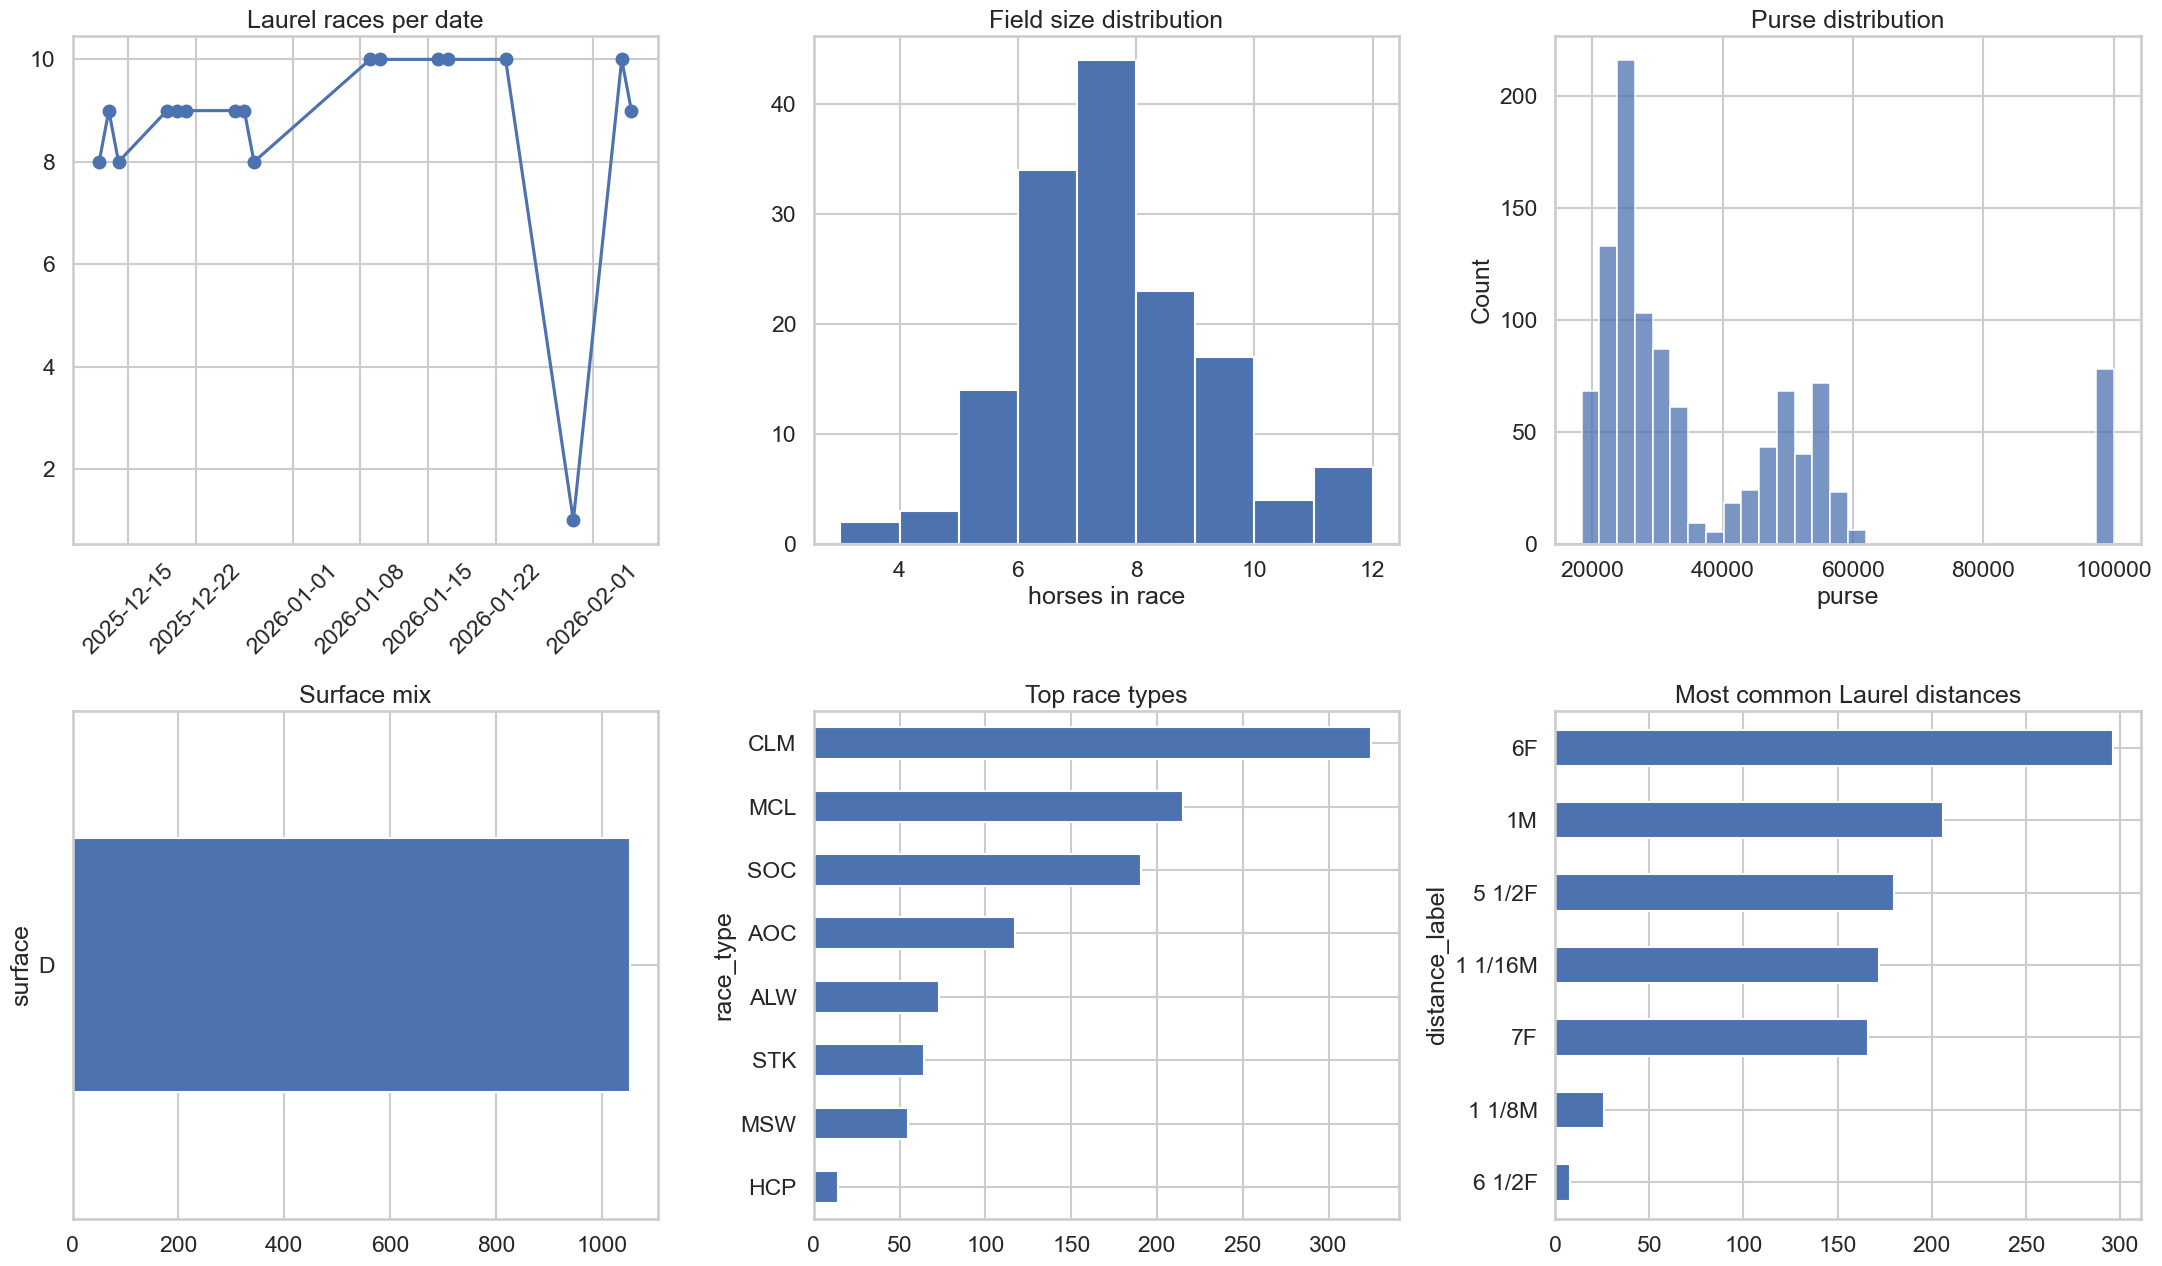

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13))

# Races over time
races_per_day = laurel_flat.groupby("race_date")["race_key"].nunique()
axes[0, 0].plot(races_per_day.index, races_per_day.values, marker="o")
axes[0, 0].set_title("Laurel races per date")
axes[0, 0].tick_params(axis="x", rotation=45)

# Horses per race
horses_per_race = laurel_flat.groupby("race_key")["horse_race_key"].nunique()
axes[0, 1].hist(horses_per_race, bins=range(int(horses_per_race.min()), int(horses_per_race.max()) + 2))
axes[0, 1].set_title("Field size distribution")
axes[0, 1].set_xlabel("horses in race")

# Purse distribution
sns.histplot(laurel_flat["purse"] if "purse" in laurel_flat.columns else laurel_flat["target_purse"], bins=30, ax=axes[0, 2])
axes[0, 2].set_title("Purse distribution")

# Surface mix
surface_col = "surface" if "surface" in laurel_flat.columns else "target_surface"
laurel_flat[surface_col].value_counts(dropna=False).sort_values().plot(kind="barh", ax=axes[1, 0])
axes[1, 0].set_title("Surface mix")

# Race type mix
race_type_col = "race_type" if "race_type" in laurel_flat.columns else "target_race_type"
laurel_flat[race_type_col].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[1, 1])
axes[1, 1].set_title("Top race types")

# Distance mix
distance_col = "distance_label" if "distance_label" in laurel_flat.columns else "distance"
laurel_flat[distance_col].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[1, 2])
axes[1, 2].set_title("Most common Laurel distances")

plt.tight_layout()
plt.show()

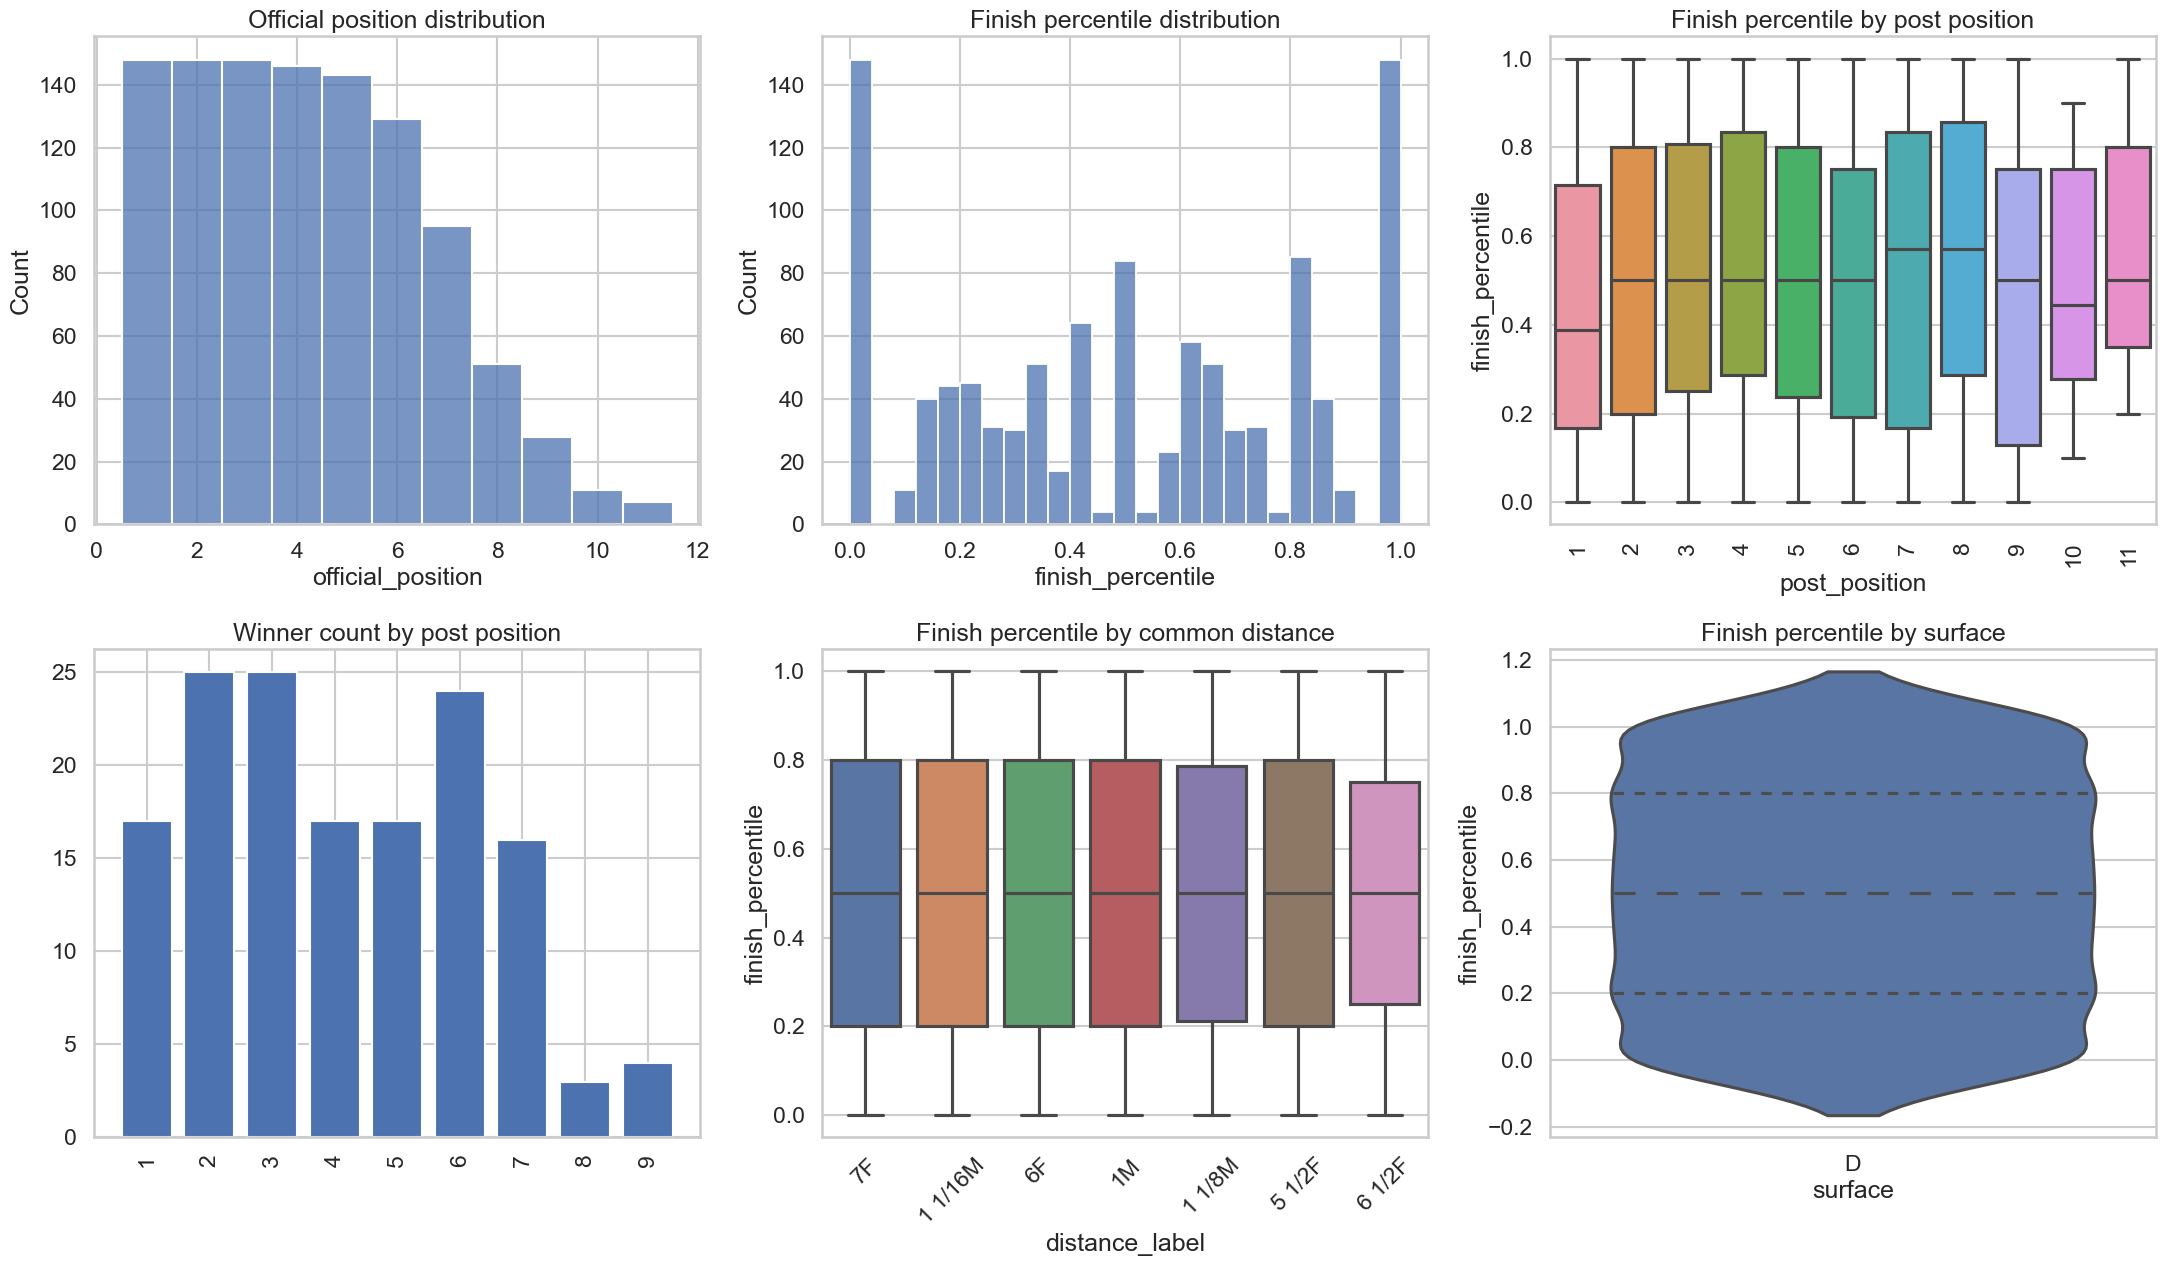

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13))

# Outcome distribution
sns.histplot(laurel_flat["official_position"], discrete=True, ax=axes[0, 0])
axes[0, 0].set_title("Official position distribution")

sns.histplot(laurel_flat["finish_percentile"], bins=25, ax=axes[0, 1])
axes[0, 1].set_title("Finish percentile distribution")

sns.boxplot(data=laurel_flat, x="post_position", y="finish_percentile", ax=axes[0, 2])
axes[0, 2].set_title("Finish percentile by post position")
axes[0, 2].tick_params(axis="x", rotation=90)

# Winners by post
winners_by_post = laurel_flat.loc[laurel_flat["is_winner"] == 1, "post_position"].value_counts().sort_index()
axes[1, 0].bar(winners_by_post.index.astype(str), winners_by_post.values)
axes[1, 0].set_title("Winner count by post position")
axes[1, 0].tick_params(axis="x", rotation=90)

# Finish percentile by distance
top_distances = laurel_flat[distance_col].value_counts().head(8).index
sns.boxplot(
    data=laurel_flat[laurel_flat[distance_col].isin(top_distances)],
    x=distance_col,
    y="finish_percentile",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Finish percentile by common distance")
axes[1, 1].tick_params(axis="x", rotation=45)

# Finish percentile by surface
sns.violinplot(data=laurel_flat, x=surface_col, y="finish_percentile", ax=axes[1, 2], inner="quartile")
axes[1, 2].set_title("Finish percentile by surface")

plt.tight_layout()
plt.show()

## 4. Historical PP coverage and traditional-racing structure

Now we move to the historical **traditional** past-performance table.

The most important questions here are:
- how many prior starts do horses have in the workbook?
- how often do those prior starts carry GPS coverage?
- how do point-of-call fields vary across distance?

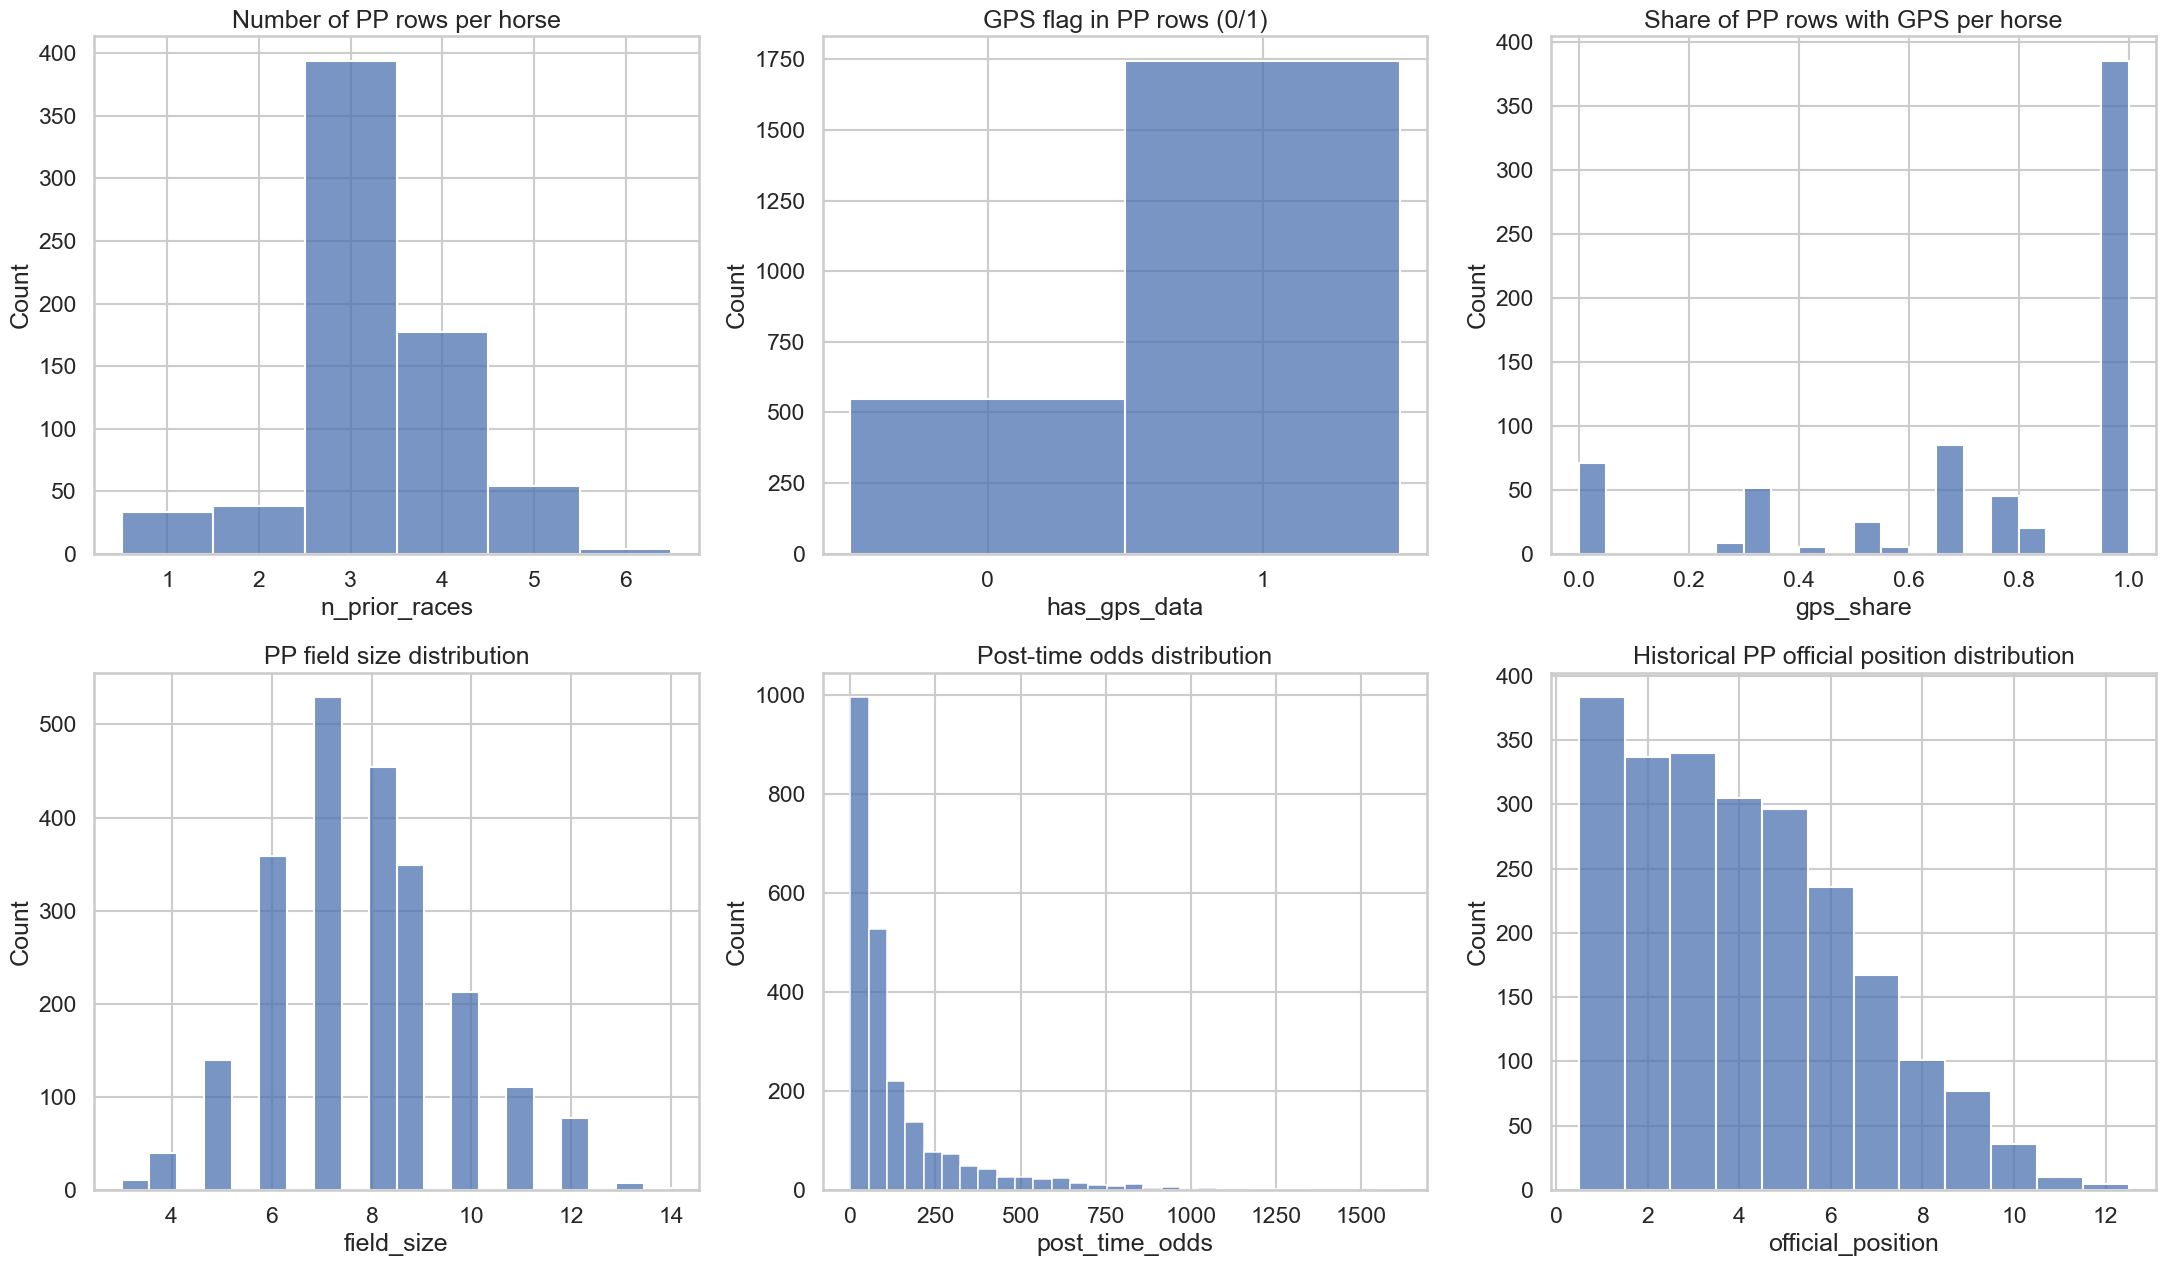

In [15]:
pp_horse_counts = (
    pps_clean.groupby("registration_number")["pp_race_key"]
    .nunique()
    .rename("n_prior_races")
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(22, 13))

sns.histplot(pp_horse_counts["n_prior_races"], discrete=True, ax=axes[0, 0])
axes[0, 0].set_title("Number of PP rows per horse")

if "has_gps_data" in pps_clean.columns:
    sns.histplot(pps_clean["has_gps_data"], discrete=True, ax=axes[0, 1])
    axes[0, 1].set_title("GPS flag in PP rows (0/1)")
    axes[0, 1].set_xticks([0, 1])

    gps_share_by_horse = (
        pps_clean.groupby("registration_number")["has_gps_data"]
        .mean()
        .reset_index(name="gps_share")
    )
    sns.histplot(gps_share_by_horse["gps_share"], bins=20, ax=axes[0, 2])
    axes[0, 2].set_title("Share of PP rows with GPS per horse")

sns.histplot(pps_clean["field_size"], bins=20, ax=axes[1, 0])
axes[1, 0].set_title("PP field size distribution")

sns.histplot(pps_clean["post_time_odds"], bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Post-time odds distribution")

sns.histplot(pps_clean["official_position"], discrete=True, ax=axes[1, 2])
axes[1, 2].set_title("Historical PP official position distribution")

plt.tight_layout()
plt.show()

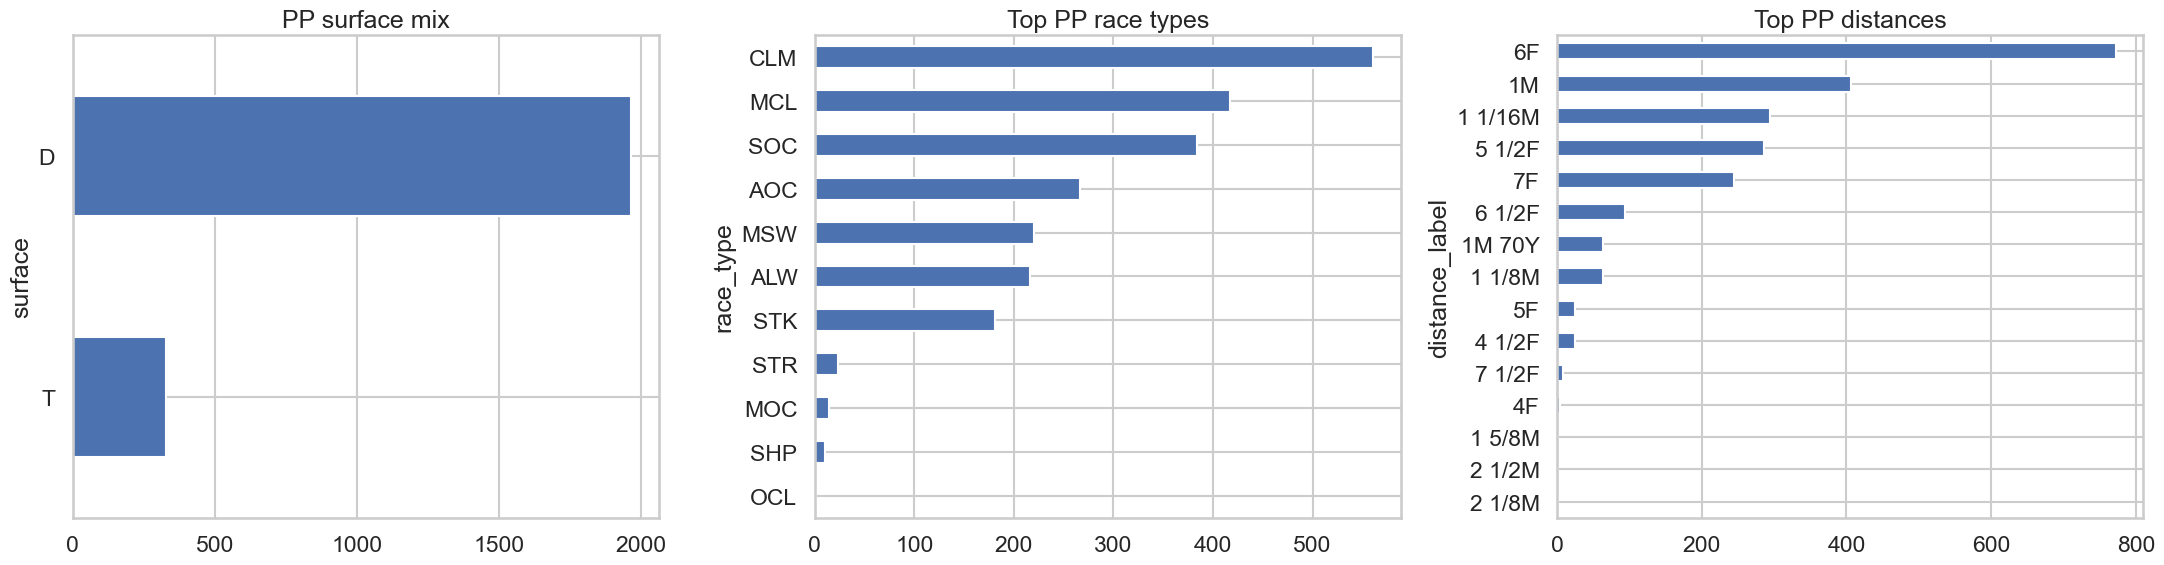

In [16]:
# Surface / distance / race-type composition in PPS
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

pps_clean["surface"].value_counts(dropna=False).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("PP surface mix")

pps_clean["race_type"].value_counts().head(15).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top PP race types")

pps_clean["distance_label"].value_counts().head(15).sort_values().plot(kind="barh", ax=axes[2])
axes[2].set_title("Top PP distances")

plt.tight_layout()
plt.show()

## 5. Point-of-call audit

This section is one of the most important in the whole EDA notebook.

The PP table uses a *distance-dependent* point-of-call structure:
- some races only have a few meaningful calls
- some columns are effectively placeholders for races whose chart structure uses fewer calls

We want to see:
- how many active point-of-calls each PP row really has
- which point-of-call columns are active for which distance labels
- whether `0` behaves like “not active / not applicable” for some columns

In [17]:
poc_position_cols = [c for c in pps_clean.columns if c.startswith("position_at_point_of_call_")]
poc_behind_cols = [c for c in pps_clean.columns if c.startswith("length_behind_at_poc_")]
poc_ahead_cols = [c for c in pps_clean.columns if c.startswith("length_ahead_at_poc_")]

pps_clean["n_active_pocs"] = pps_clean[poc_position_cols].fillna(0).gt(0).sum(axis=1)

# Build a distance x POC heatmap table
distance_order = (
    pps_clean[["distance_label", "distance_furlongs"]]
    .drop_duplicates()
    .sort_values(["distance_furlongs", "distance_label"])
    ["distance_label"]
    .tolist()
)

active_poc_heat = (
    pps_clean.groupby("distance_label")[poc_position_cols]
    .apply(lambda df: df.fillna(0).gt(0).mean())
    .reindex(distance_order)
)
active_poc_heat.head()

,position_at_point_of_call_1,position_at_point_of_call_2,position_at_point_of_call_3,position_at_point_of_call_4,position_at_point_of_call_5
distance_label,,,,,
4F,1.0,0.0,0.0,0.0,1.0
4 1/2F,1.0,0.0,0.0,0.0,1.0
5F,1.0,1.0,0.0,0.0,1.0
5 1/2F,1.0,1.0,0.0,0.0,1.0
6F,1.0,1.0,0.0,0.0,1.0


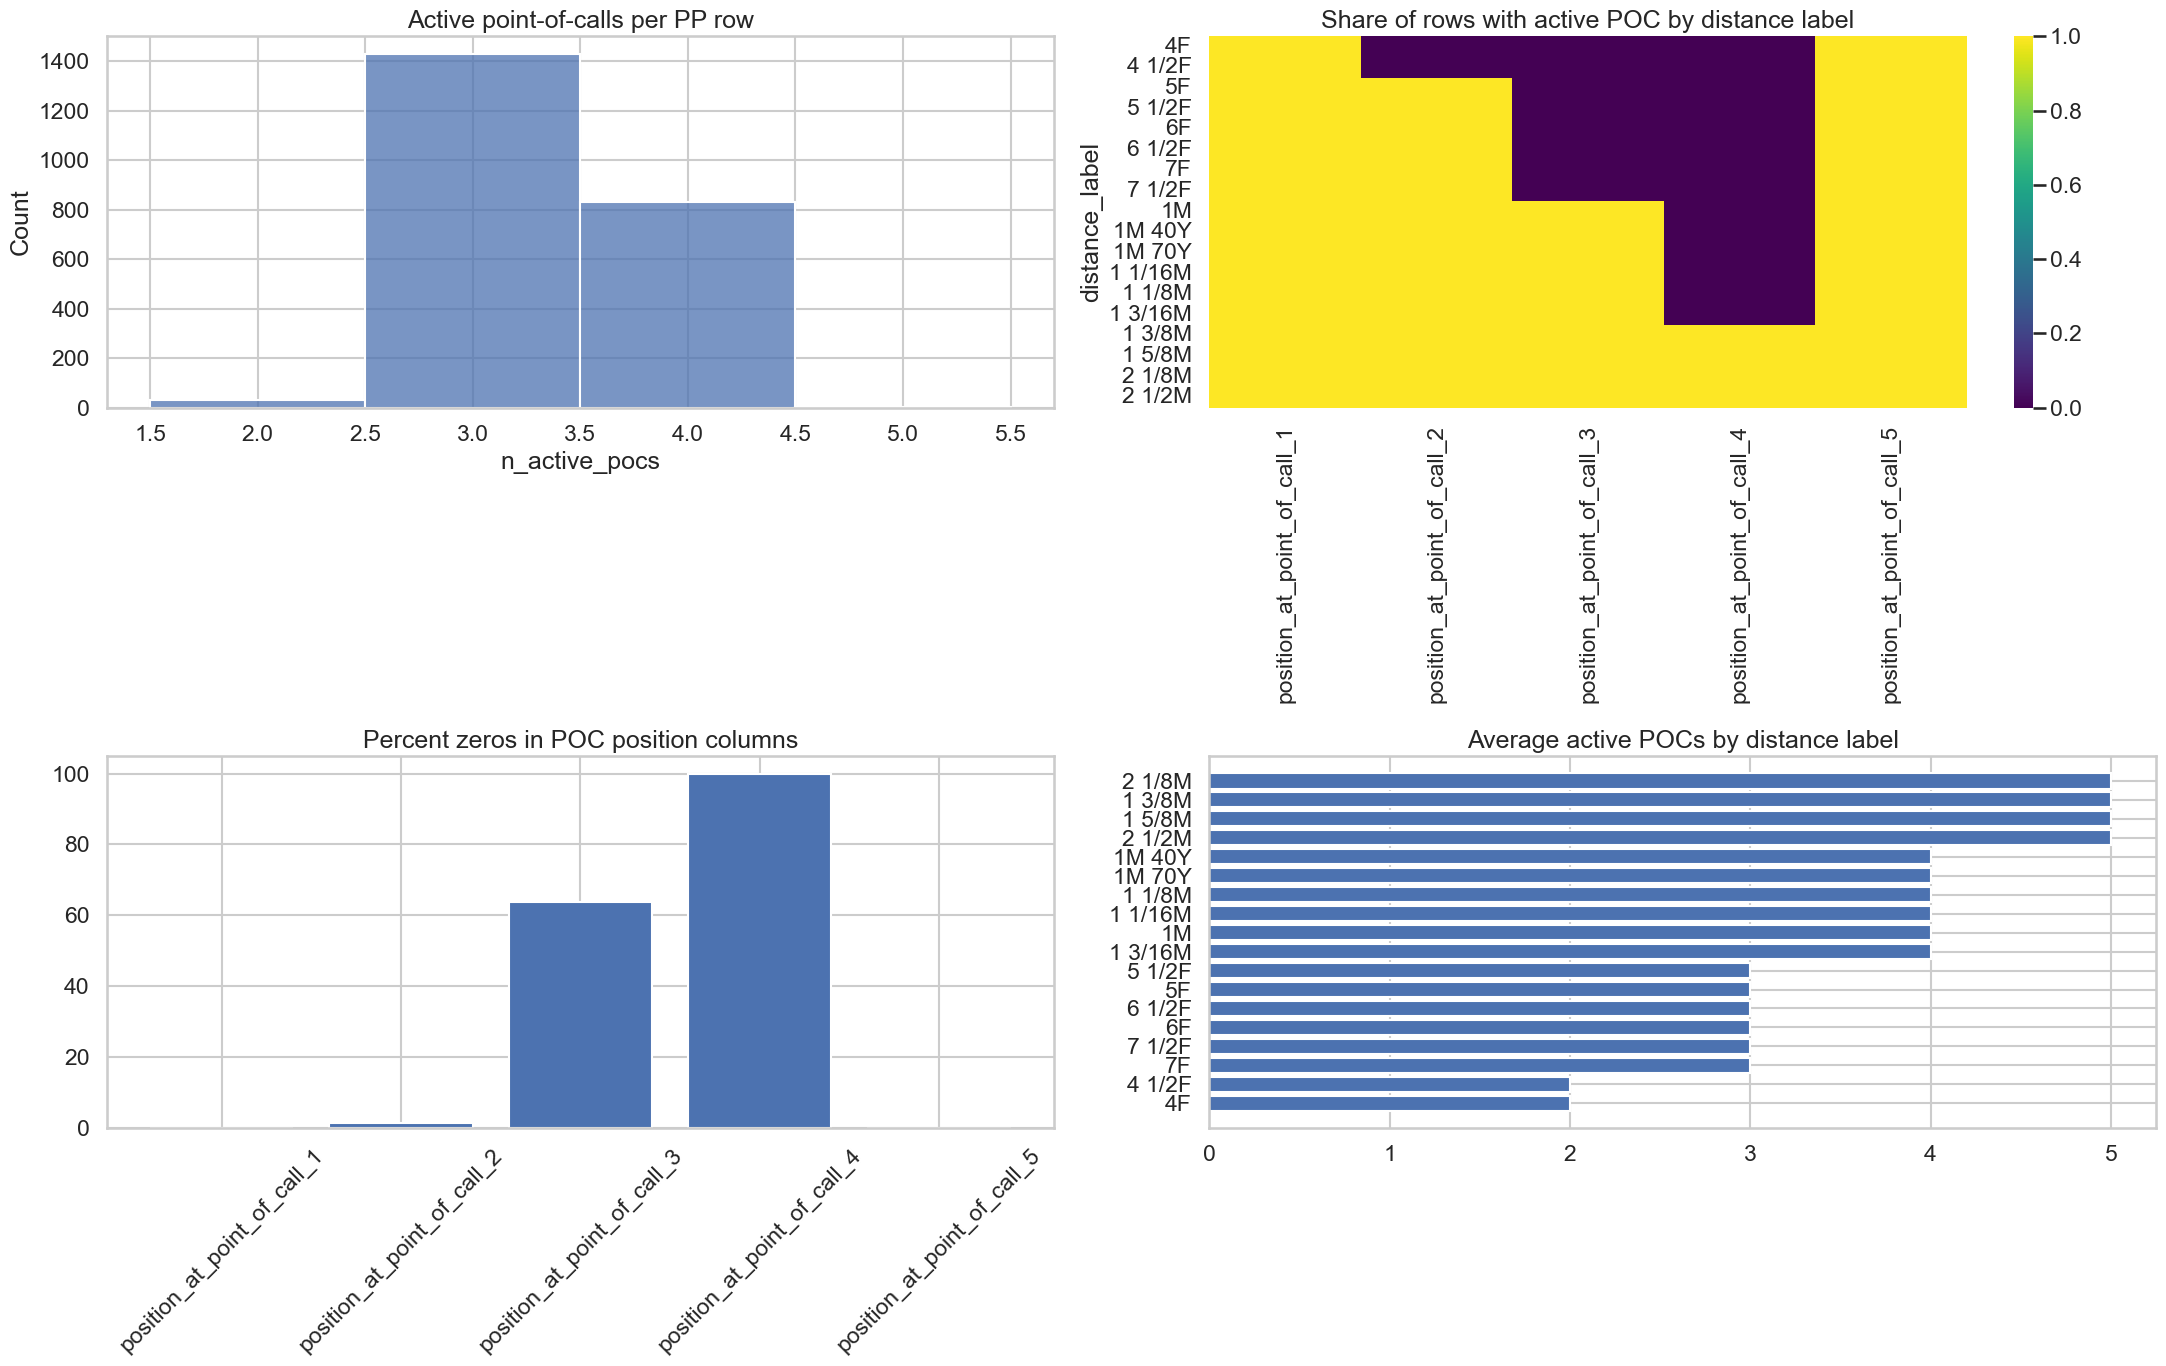

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(22, 14))

sns.histplot(pps_clean["n_active_pocs"], discrete=True, ax=axes[0, 0])
axes[0, 0].set_title("Active point-of-calls per PP row")

# Heatmap of active POCs by distance label (limited to top 20 distances for readability)
top_distance_labels = pps_clean["distance_label"].value_counts().head(20).index
sns.heatmap(
    active_poc_heat.loc[active_poc_heat.index.isin(top_distance_labels)],
    cmap="viridis",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Share of rows with active POC by distance label")

# Share of zeros in each POC position column
zero_share = (pps_clean[poc_position_cols].fillna(0).eq(0).mean() * 100).sort_index()
axes[1, 0].bar(zero_share.index, zero_share.values)
axes[1, 0].set_title("Percent zeros in POC position columns")
axes[1, 0].tick_params(axis="x", rotation=45)

# Number of active POCs by distance
poc_by_dist = (
    pps_clean.groupby("distance_label")["n_active_pocs"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .sort_values()
)
axes[1, 1].barh(poc_by_dist.index, poc_by_dist.values)
axes[1, 1].set_title("Average active POCs by distance label")

plt.tight_layout()
plt.show()

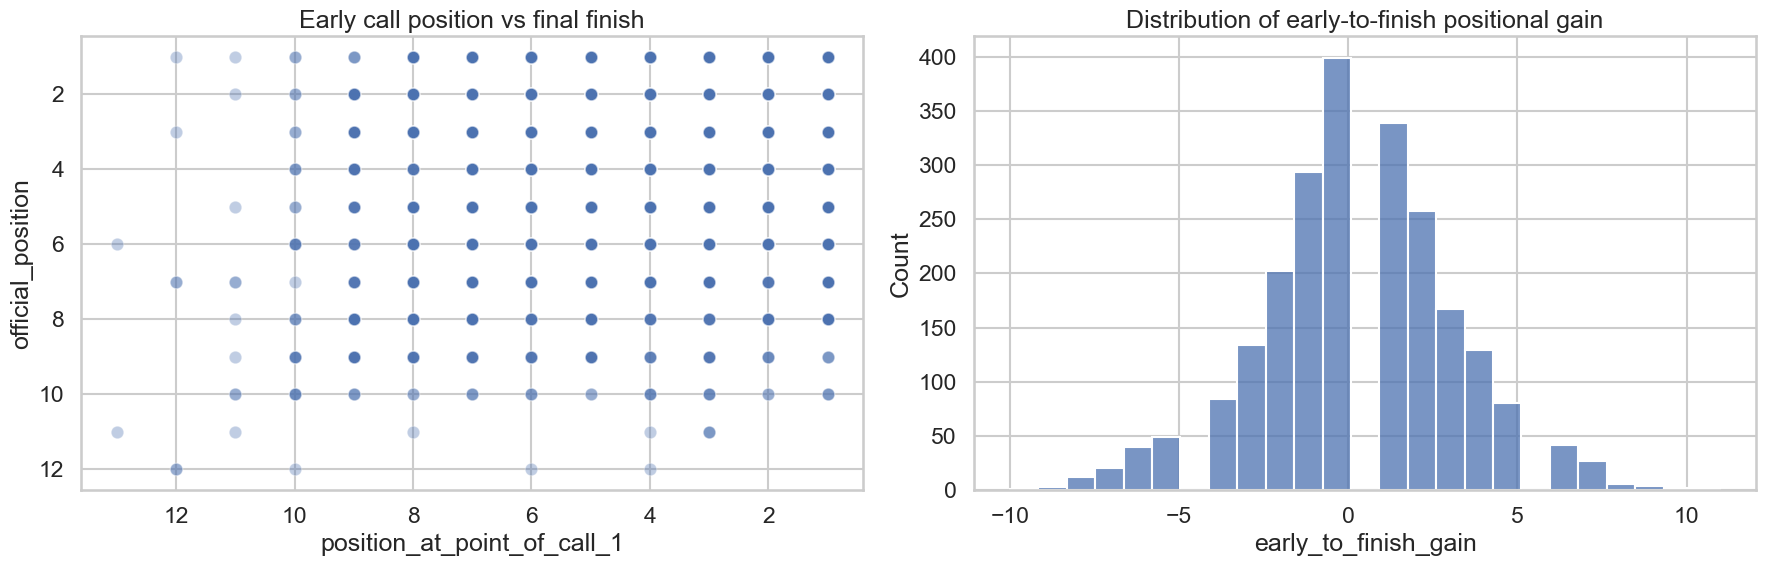

In [19]:
# Early/late POC relationship previews
valid_early_late = pps_clean.query("position_at_point_of_call_1 > 0 and position_at_point_of_call_5 > 0").copy()

if not valid_early_late.empty:
    valid_early_late["early_to_finish_gain"] = (
        valid_early_late["position_at_point_of_call_1"] - valid_early_late["official_position"]
    )
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.scatterplot(
        data=valid_early_late.sample(min(2000, len(valid_early_late)), random_state=42),
        x="position_at_point_of_call_1",
        y="official_position",
        alpha=0.35,
        ax=axes[0],
    )
    axes[0].set_title("Early call position vs final finish")
    axes[0].invert_xaxis()
    axes[0].invert_yaxis()

    sns.histplot(valid_early_late["early_to_finish_gain"], bins=25, ax=axes[1])
    axes[1].set_title("Distribution of early-to-finish positional gain")

    plt.tight_layout()
    plt.show()

## 6. Historical GPS audit

The GPS PPS table is the historical GPS counterpart to the traditional PP table.

Here we inspect:
- how many historical GPS races are available
- gate structure and gate density
- GPS-based mechanical quantities like distance ran, strides, and meters per stride
- simple finish-row summaries such as extra distance covered

In [20]:
gps_pp_clean["meters_per_stride"] = (
    gps_pp_clean["distance_ran"] / gps_pp_clean["strides"]
).replace([np.inf, -np.inf], np.nan)

gps_pp_clean["is_finish_row"] = gps_pp_clean.groupby("pp_race_key")["gate"].transform("min").eq(gps_pp_clean["gate"])

gps_finish = (
    gps_pp_clean.loc[gps_pp_clean["is_finish_row"]]
    .copy()
    .assign(
        extra_distance_m=lambda df: df["cumulative_distance_ran"] - df["distance_meters_expected"],
        distance_efficiency_ratio=lambda df: df["cumulative_distance_ran"] / df["distance_meters_expected"],
    )
)
gps_finish.head()

,horse_name,registration_number,pp_track,pp_race_date,pp_race_number,race_type,grade,distance_id,distance_unit,about_distance_indicator,published_value,surface,post_position,gate,position,official_position,sectional_time,running_time,time_behind,distance_behind,distance_ran,cumulative_distance_ran,strides,cumulative_strides,purse,field_size,is_about_distance,is_graded_race,distance_furlongs,distance_meters_expected,distance_label,is_nonstandard_distance,pp_race_key,meters_per_stride,is_finish_row,extra_distance_m,distance_efficiency_ratio
15,Bode's Maker,15000089,LRL,2025-11-22,2,SOC,NaN,8.0,F,NaN,1M,T,7,0.0,4,4,6.34,98.442,0.362,5.4,100.6,1624.8,14.2,229.1,26520,11,0,0,8.0,1609.344,1M,0,15000089|LRL|2025-11-22|2,7.084507,True,15.456,1.009604
32,Bode's Maker,15000089,LRL,2025-11-01,6,SOC,NaN,8.5,F,NaN,1 1/16M,T,6,0.0,2,2,6.40,103.708,0.198,3.0,100.6,1724.6,14.7,244.3,27020,12,0,0,8.5,1709.928,1 1/16M,0,15000089|LRL|2025-11-01|6,6.843537,True,14.672,1.008580
48,Bode's Maker,15000089,LRL,2025-10-04,9,SOC,NaN,8.0,F,NaN,1M,T,9,0.0,1,1,6.13,95.600,0.000,0.0,100.6,1618.1,14.2,226.2,25520,9,0,0,8.0,1609.344,1M,0,15000089|LRL|2025-10-04|9,7.084507,True,8.756,1.005441
61,Tiberius Mercurius,16009053,AQU,2025-12-31,8,CLM,NaN,6.5,F,NaN,6 1/2F,D,4,0.0,10,10,6.89,81.001,1.291,17.4,100.6,1312.7,14.6,181.6,28000,11,0,0,6.5,1307.592,6 1/2F,0,16009053|AQU|2025-12-31|8,6.890411,True,5.108,1.003906
77,Tiberius Mercurius,16009053,AQU,2025-12-10,6,CLM,NaN,8.0,F,NaN,1M,D,1,0.0,4,4,7.59,101.637,1.187,16.1,100.6,1613.8,15.7,228.1,28000,7,0,0,8.0,1609.344,1M,0,16009053|AQU|2025-12-10|6,6.407643,True,4.456,1.002769


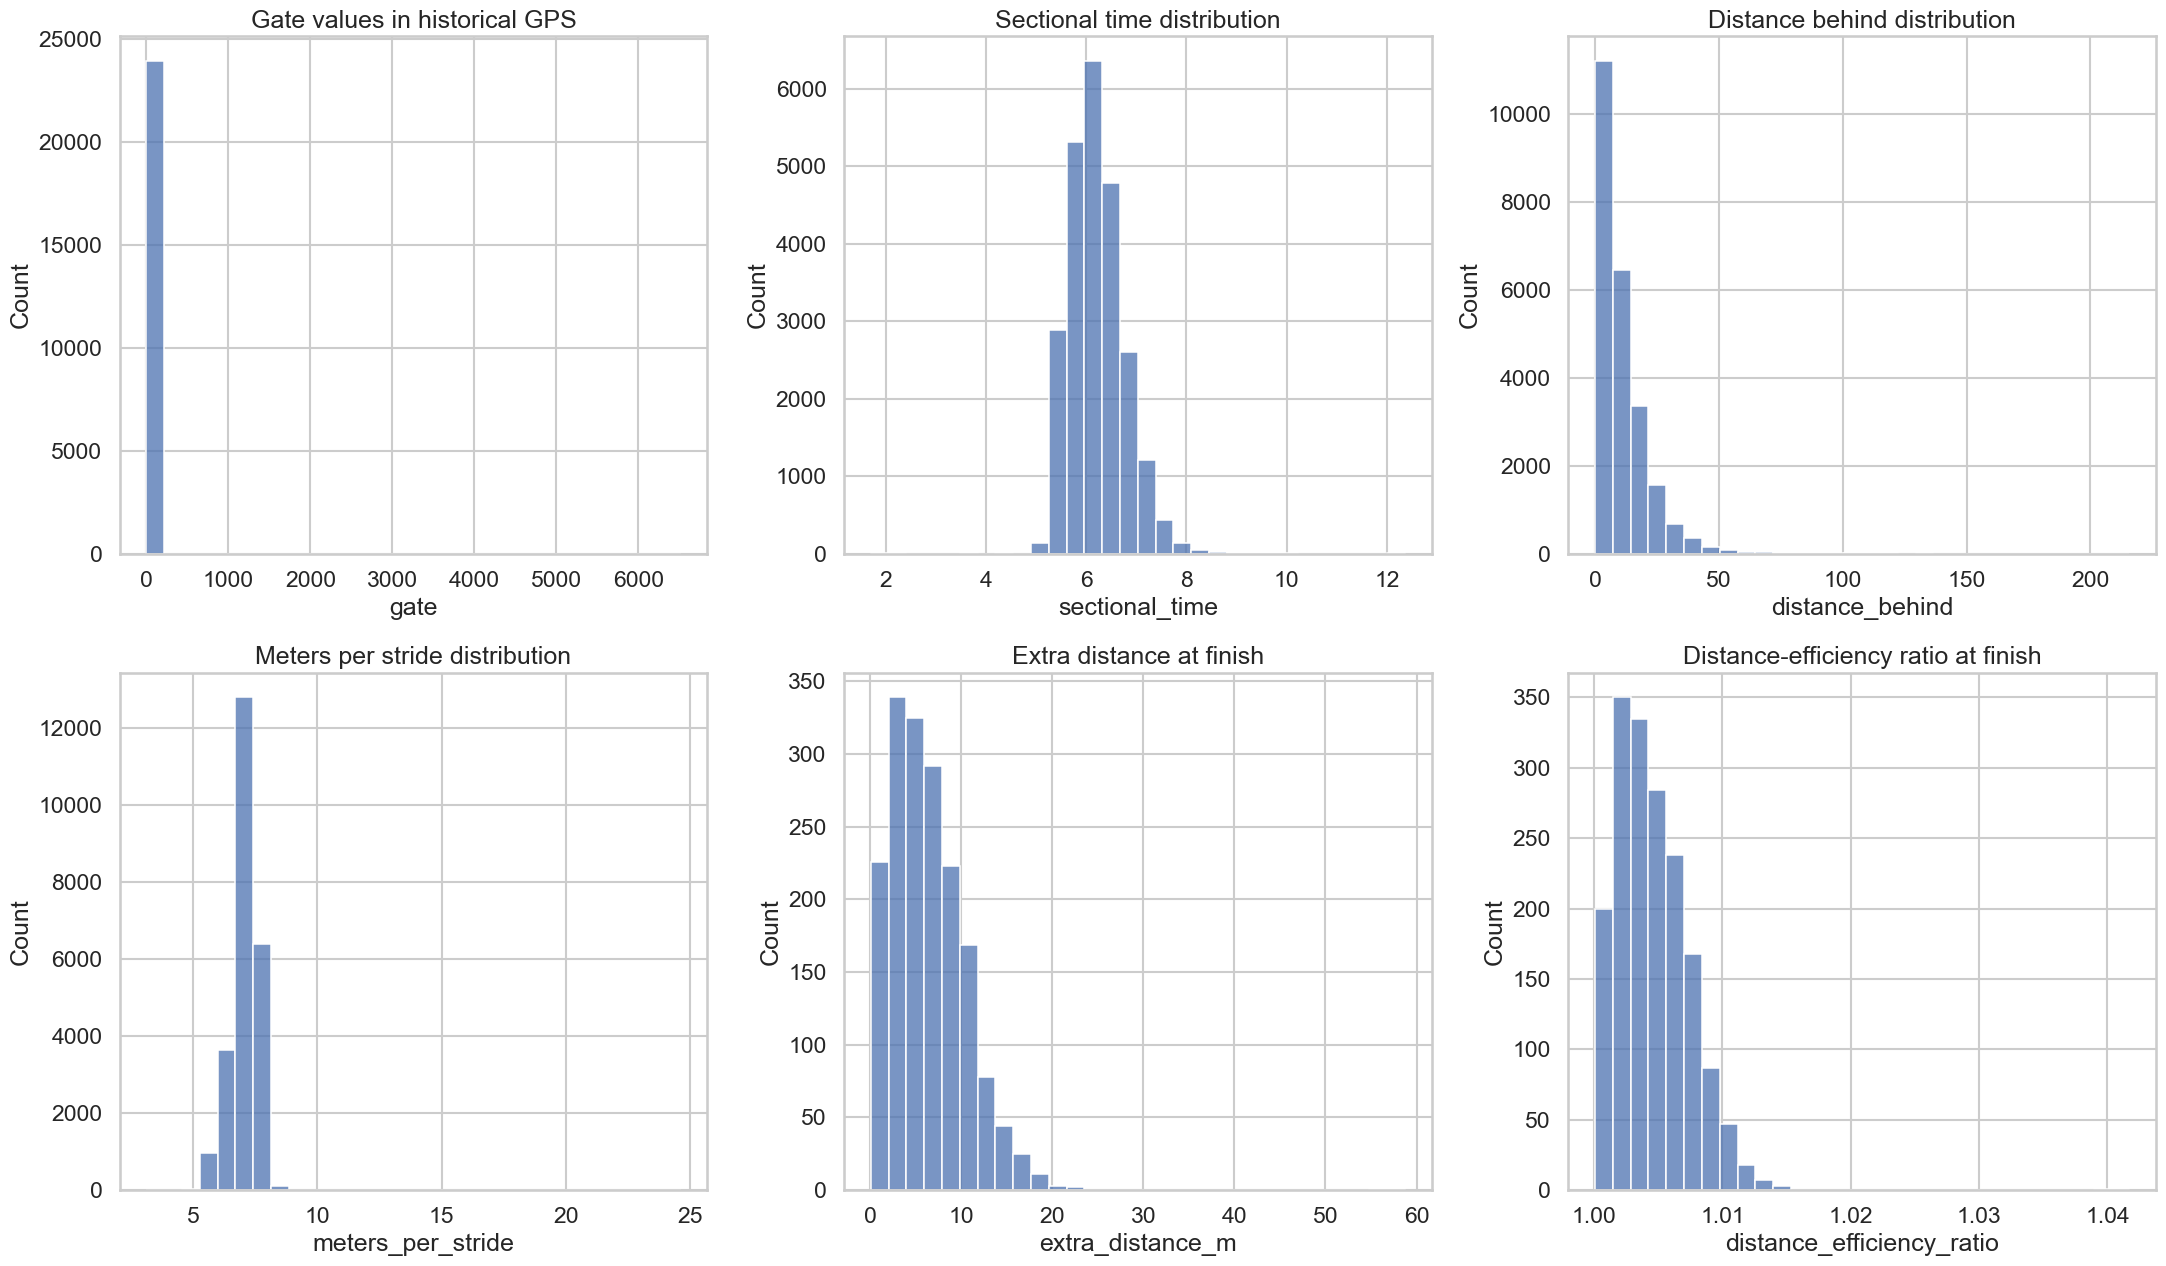

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13))

sns.histplot(gps_pp_clean["gate"], bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Gate values in historical GPS")

sns.histplot(gps_pp_clean["sectional_time"], bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Sectional time distribution")

sns.histplot(gps_pp_clean["distance_behind"], bins=30, ax=axes[0, 2])
axes[0, 2].set_title("Distance behind distribution")

sns.histplot(gps_pp_clean["meters_per_stride"].dropna(), bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Meters per stride distribution")

sns.histplot(gps_finish["extra_distance_m"].dropna(), bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Extra distance at finish")

sns.histplot(gps_finish["distance_efficiency_ratio"].dropna(), bins=30, ax=axes[1, 2])
axes[1, 2].set_title("Distance-efficiency ratio at finish")

plt.tight_layout()
plt.show()

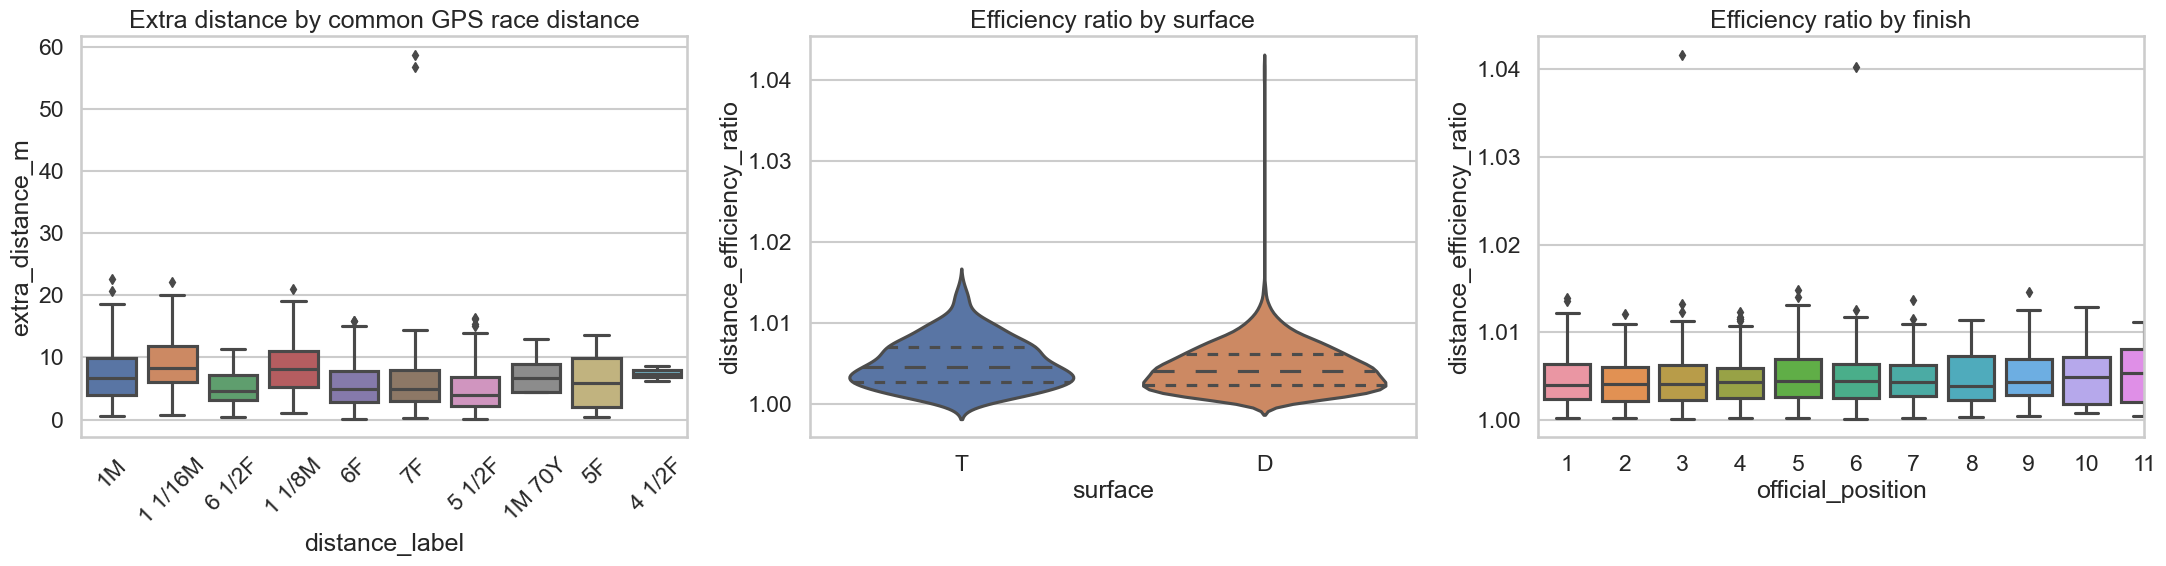

In [22]:
# GPS distributions by distance and surface
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

common_gps_distances = gps_finish["distance_label"].value_counts().head(10).index
sns.boxplot(
    data=gps_finish[gps_finish["distance_label"].isin(common_gps_distances)],
    x="distance_label",
    y="extra_distance_m",
    ax=axes[0],
)
axes[0].set_title("Extra distance by common GPS race distance")
axes[0].tick_params(axis="x", rotation=45)

sns.violinplot(data=gps_finish, x="surface", y="distance_efficiency_ratio", ax=axes[1], inner="quartile")
axes[1].set_title("Efficiency ratio by surface")

sns.boxplot(data=gps_finish, x="official_position", y="distance_efficiency_ratio", ax=axes[2])
axes[2].set_title("Efficiency ratio by finish")
axes[2].set_xlim(-0.5, min(10, gps_finish["official_position"].max()+0.5))

plt.tight_layout()
plt.show()

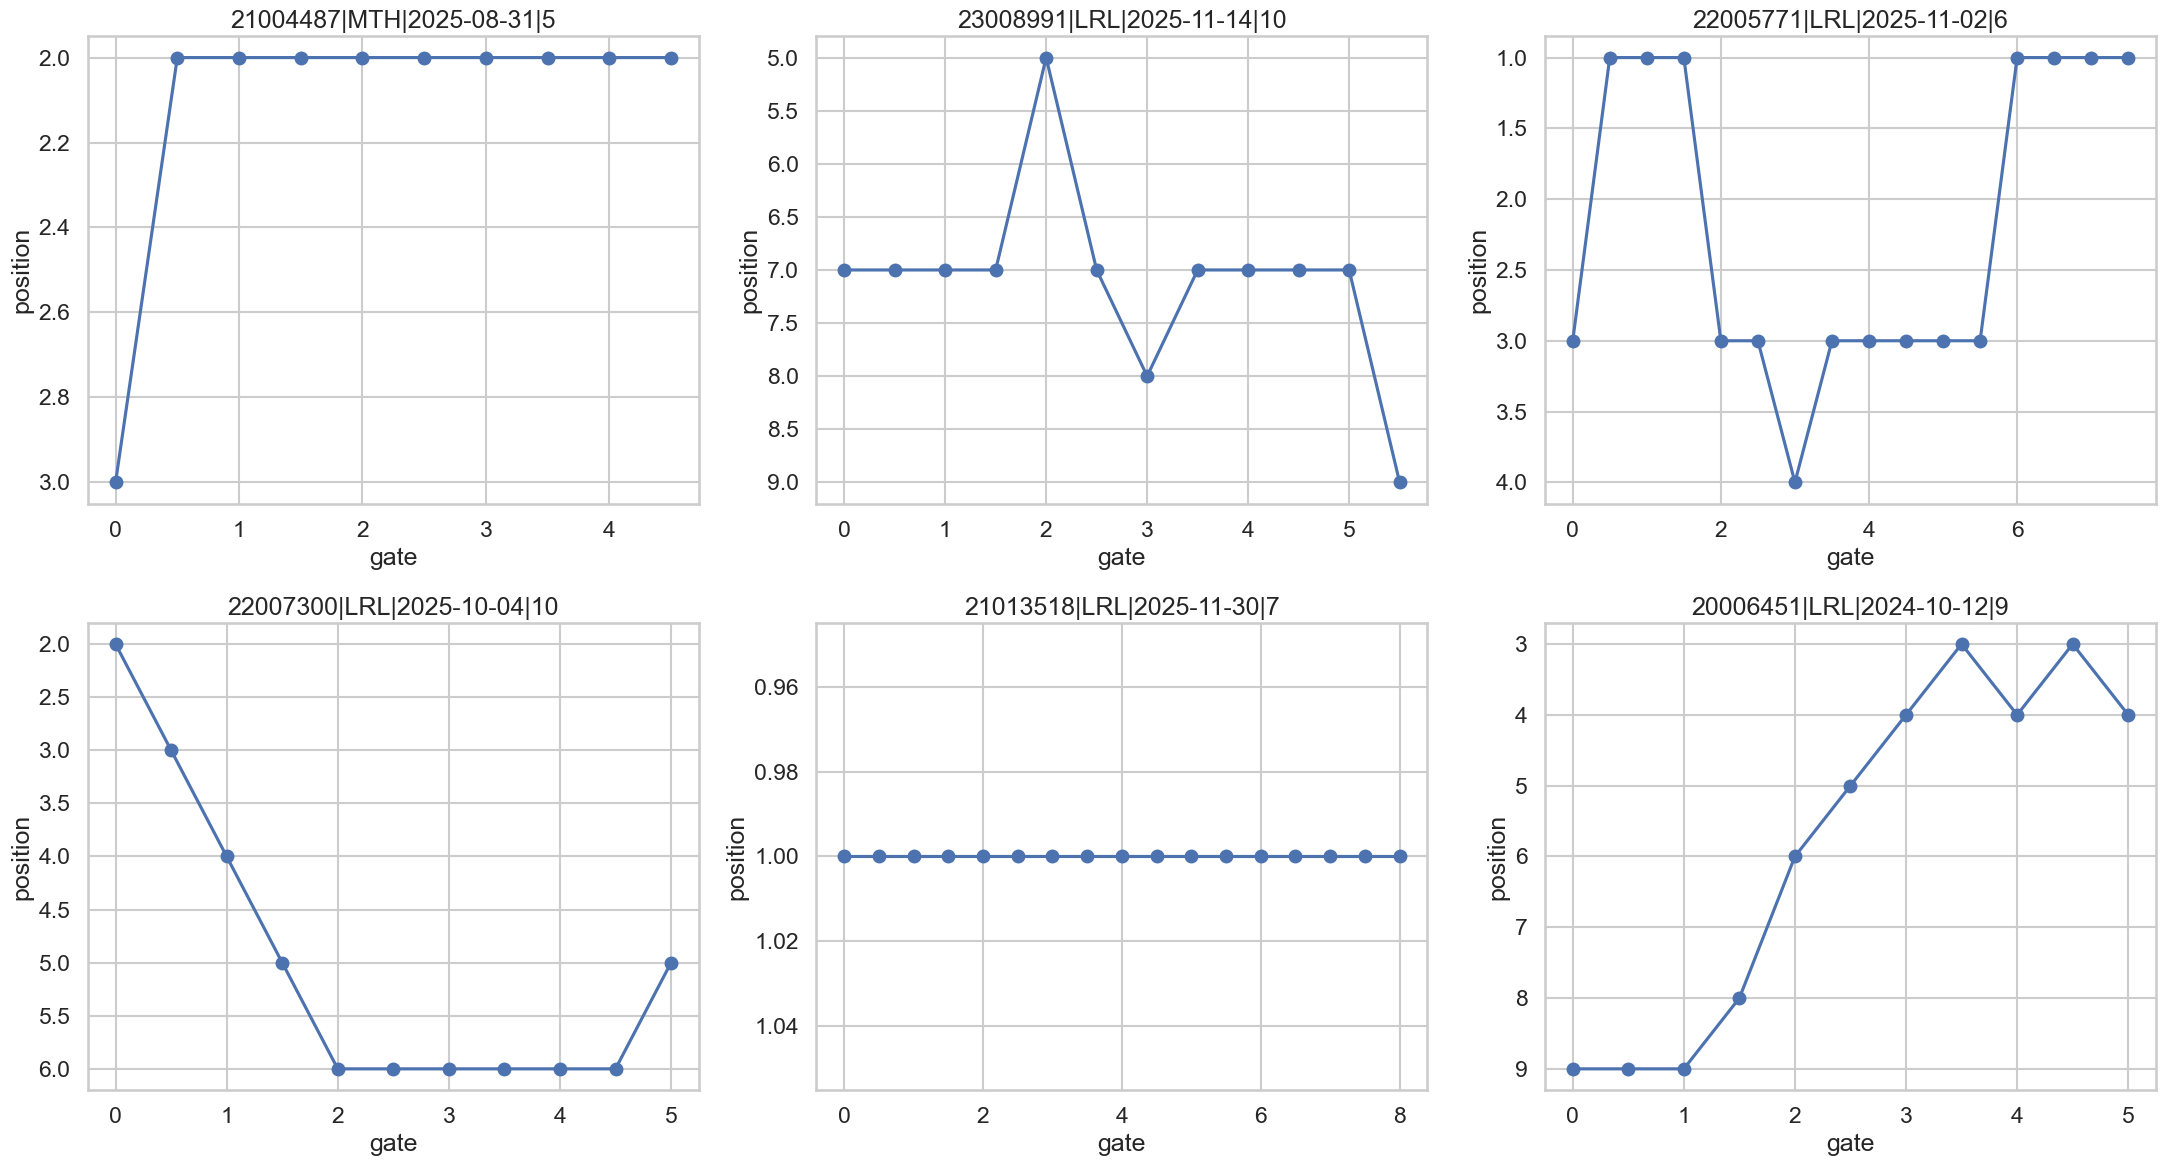

In [23]:
# Sample gate trajectory plots for intuition
sample_keys = gps_pp_clean["pp_race_key"].dropna().drop_duplicates().sample(min(6, gps_pp_clean["pp_race_key"].nunique()), random_state=42)
sample_traces = gps_pp_clean[gps_pp_clean["pp_race_key"].isin(sample_keys)].copy()

fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharex=False)
for ax, key in zip(axes.flatten(), sample_keys):
    sub = sample_traces[sample_traces["pp_race_key"] == key].sort_values("gate", ascending=False)
    ax.plot(sub["gate"], sub["position"], marker="o")
    ax.set_title(str(key))
    ax.set_xlabel("gate")
    ax.set_ylabel("position")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Join-path and coverage audit

The conceptual join path is:

**current Laurel target horse-race**  
→ **historical PP rows**  
→ **historical GPS rows for the PP races that had GPS**

We do **not** build the merged modeling table here, but we absolutely should verify that the join path is valid.

In [24]:
coverage_rows = []

# Laurel horse coverage in PPS
if "registration_number" in laurel_flat.columns and "registration_number" in pps_clean.columns:
    laurel_horses = set(laurel_flat["registration_number"].astype(str))
    pps_horses = set(pps_clean["registration_number"].astype(str))
    coverage_rows.append(
        {
            "coverage_check": "Laurel horses represented in PPS",
            "numerator": len(laurel_horses & pps_horses),
            "denominator": len(laurel_horses),
            "share": len(laurel_horses & pps_horses) / max(1, len(laurel_horses)),
        }
    )

# GPS-flagged PP rows matched in GPS PPS
if "has_gps_data" in pps_clean.columns and "pp_race_key" in pps_clean.columns and "pp_race_key" in gps_pp_clean.columns:
    pp_flagged = set(pps_clean.loc[pps_clean["has_gps_data"] == 1, "pp_race_key"].dropna())
    gps_keys = set(gps_pp_clean["pp_race_key"].dropna())
    coverage_rows.append(
        {
            "coverage_check": "GPS-flagged PP race keys matched in GPS PPS",
            "numerator": len(pp_flagged & gps_keys),
            "denominator": len(pp_flagged),
            "share": len(pp_flagged & gps_keys) / max(1, len(pp_flagged)),
        }
    )

coverage_report = pd.DataFrame(coverage_rows)
coverage_report

,coverage_check,numerator,denominator,share
0,Laurel horses represented in PPS,700,729,0.960219
1,GPS-flagged PP race keys matched in GPS PPS,1739,1744,0.997133


In [25]:
# Unmatched GPS-flagged PP rows
if "has_gps_data" in pps_clean.columns and "pp_race_key" in pps_clean.columns and "pp_race_key" in gps_pp_clean.columns:
    gps_keys = set(gps_pp_clean["pp_race_key"].dropna())
    unmatched_pps = (
        pps_clean.loc[pps_clean["has_gps_data"] == 1]
        .loc[lambda df: ~df["pp_race_key"].isin(gps_keys)]
        .sort_values(["registration_number", "pp_race_date", "pp_race_number"])
        .copy()
    )
else:
    unmatched_pps = pd.DataFrame()

unmatched_pps.head(20)

,gps_data_flag,registration_number,horse_name,pp_track,pp_race_date,pp_race_number,pp_country,race_type,grade,distance_id,distance_unit,about_distance_indicator,distance,surface,post_position,position_at_point_of_call_1,position_at_point_of_call_2,position_at_point_of_call_3,position_at_point_of_call_4,position_at_point_of_call_5,official_position,length_behind_at_poc_1,length_behind_at_poc_2,length_behind_at_poc_3,length_behind_at_poc_4,length_behind_at_poc_5,length_behind_at_finish,length_ahead_at_poc_1,length_ahead_at_poc_2,length_ahead_at_poc_3,length_ahead_at_poc_4,length_ahead_at_poc_5,length_ahead_at_finish,post_time_odds,field_size,purse,is_about_distance,is_graded_race,has_gps_data,distance_furlongs,distance_meters_expected,distance_label,is_nonstandard_distance,pp_race_key,n_active_pocs
357,X,20004104,Lucked In,LRL,2025-09-13,9,USA,CLM,NaN,7.0,F,NaN,7F,D,7,7.0,6.0,NaN,NaN,7.0,7,920.0,1060.0,0.0,0.0,1760.0,NaN,0.0,400.0,0.0,0.0,0.0,NaN,34,7,22560,0,0,1,7.0,1408.176,7F,0,20004104|LRL|2025-09-13|9,3
431,X,20011779,Gluckstadt,LRL,2025-11-23,7,USA,SOC,NaN,8.0,F,NaN,1M,D,2,10.0,10.0,10.0,NaN,10.0,10,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,297,10,39055,0,0,1,8.0,1609.344,1M,0,20011779|LRL|2025-11-23|7,4
671,X,21004535,Proud Divi,LRL,2025-11-07,2,USA,SOC,NaN,6.0,F,NaN,6F,D,3,7.0,7.0,NaN,NaN,7.0,7,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,32,7,30370,0,0,1,6.0,1207.008,6F,0,21004535|LRL|2025-11-07|2,3
728,X,21006267,Firstlady Rosalynn,AQU,2025-11-28,3,USA,CLM,NaN,6.5,F,NaN,6 1/2F,D,3,5.0,5.0,NaN,NaN,5.0,5,350.0,230.0,0.0,0.0,1350.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,34,5,38000,0,0,1,6.5,1307.592,6 1/2F,0,21006267|AQU|2025-11-28|3,3
1963,X,23007154,Broadside Salvo,LRL,2025-10-25,9,USA,MSW,NaN,6.0,F,NaN,6F,D,3,9.0,9.0,NaN,NaN,9.0,9,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1022,9,46500,0,0,1,6.0,1207.008,6F,0,23007154|LRL|2025-10-25|9,3


## 8. Save summary outputs for your write-up or team discussion

This last section writes out a few compact tables that are useful in slides, notes, or a faculty/advisor check-in.

In [26]:
summary_tables = {
    "inventory.csv": inventory,
    "missingness_summary.csv": missing_all,
    "grain_report.csv": grain_report,
    "coverage_report.csv": coverage_report,
    "unmatched_gps_flag_pp_rows.csv": unmatched_pps,
}

if "n_active_pocs" in pps_clean.columns:
    poc_distance_summary = (
        pps_clean.groupby(["distance_label", "distance_furlongs"], dropna=False)
        .agg(
            n_rows=("pp_race_key", "size"),
            avg_active_pocs=("n_active_pocs", "mean"),
            share_with_gps=("has_gps_data", "mean") if "has_gps_data" in pps_clean.columns else ("official_position", "size"),
        )
        .reset_index()
        .sort_values(["distance_furlongs", "distance_label"])
    )
    summary_tables["poc_distance_summary.csv"] = poc_distance_summary

if "distance_efficiency_ratio" in gps_finish.columns:
    gps_distance_summary = (
        gps_finish.groupby(["distance_label", "surface"], dropna=False)
        .agg(
            n_races=("pp_race_key", "size"),
            mean_extra_distance_m=("extra_distance_m", "mean"),
            mean_efficiency=("distance_efficiency_ratio", "mean"),
        )
        .reset_index()
        .sort_values(["n_races", "distance_label"], ascending=[False, True])
    )
    summary_tables["gps_distance_summary.csv"] = gps_distance_summary

for filename, table in summary_tables.items():
    table.to_csv(EDA_DIR / filename, index=False)

pd.DataFrame({"saved_file": sorted(summary_tables.keys())})

,saved_file
0,coverage_report.csv
1,gps_distance_summary.csv
2,grain_report.csv
3,inventory.csv
4,missingness_summary.csv
5,poc_distance_summary.csv
6,unmatched_gps_flag_pp_rows.csv


## Suggested takeaways to write down before moving on

When you finish this notebook, write a few bullets for yourself:

- Which missing values are structural and safe to leave alone?
- Which distance labels dominate the dataset?
- How many active point-of-calls do different distances actually use?
- How much historical GPS coverage do you have?
- Are there any unmatched GPS-flagged PP rows you should keep in mind later?
- Are there race distances or surfaces with very thin coverage that may need caution in modeling?

Those bullets make Feature Engineering much more deliberate.